## Import packages

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import ast, os, pickle, random, re
from joblib import Parallel, delayed
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from pyvis.network import Network

from sklearn.ensemble import GradientBoostingRegressor
from scipy.signal import savgol_filter
from scipy.interpolate import UnivariateSpline
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

import networkx as nx
import dowhy
from dowhy import gcm
from dowhy.gcm.auto import AssignmentQuality

/Users/rachelrobles/anaconda3/envs/mynewenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Make it easier to read
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows",1000)
pd.set_option('display.max_columns',100)

## Initialize variables

In [3]:
bootstrap = 100
data_run_label = "A_1"
data_label = data_run_label[0]
param_labels = ['A', 'B', 'C', 'D', 'E']

## Load data

In [4]:
edge_summary = pd.read_csv(f"summaries/{data_run_label}/causal_disc_edge_summary_b{bootstrap}.csv")
fit_summary = pd.read_csv(f"summaries/{data_run_label}/scm_fit_summary_b{bootstrap}.csv")
benchmark_summary = pd.read_csv(f"summaries/{data_run_label}/benchmark_comparison_b{bootstrap}.csv")
all_edges = pd.read_csv(f"summaries/{data_run_label}/causal_disc_all_edges_b{bootstrap}.csv")

In [5]:
file_name_no_std = 'nonstd_data_for_model_'+data_label+'.csv'
final_df_no_std = pd.read_csv(file_name_no_std)
file_name_std = 'std_data_for_model_'+data_label+'.csv'
final_df_std = pd.read_csv(file_name_std)
file_name_no_std_noninf = 'nonstd_data_noninf_'+data_label+'.csv'
final_df_no_std_noninf = pd.read_csv(file_name_no_std_noninf)

In [6]:
dir = Path(f"graph_objects/{data_run_label}")
graphs = {}
scms = {}

# Example filename: pc_b75_0_35_graph.pkl
pattern_1 = re.compile(
    r"(?P<model>[a-zA-Z_]+)_p(?P<param>[a-zA-Z_]+)_b(?P<bootstrap>\d+)_(?P<threshold>\d+(?:_\d+)?|[0-9]+)_(?P<type>graph)\.pkl$"
)
pattern_2 = re.compile(
    r"(?P<model>[a-zA-Z_]+)_p(?P<param>[a-zA-Z_]+)_b(?P<bootstrap>\d+)_(?P<threshold>\d+(?:_\d+)?|[0-9]+)_(?P<type>scm)\.pkl$"
)

for file in dir.glob("*.pkl"):
    print(file)
    match_1 = pattern_1.match(file.name)
    match_2 = pattern_2.match(file.name)
    if not match_1 and not match_2:
        print(f"Skipping unrecognized file: {file.name}")
        continue
    
    match = match_1 if match_1 else match_2
    model = match.group("model")
    bootstrap = int(match.group("bootstrap"))
    param = match.group("param")
    threshold = float(match.group("threshold").replace("_", "."))
    
    with open(file, "rb") as f:
        if match_1:
            G = pickle.load(f)
            # Store as nested dictionary: graphs[model][threshold][param]
            graphs.setdefault(model, {}).setdefault(threshold, {})[param] = G
        else:
            scm = pickle.load(f)
            # Store as nested dictionary: graphs[model][threshold][param]
            scms.setdefault(model, {}).setdefault(threshold, {})[param] = scm
    

print("Loaded graphs for models:")
for model, thresholds in graphs.items():
    print(f"  {model}: thresholds = {list(thresholds.keys())}")
print("Loaded scms for models:")
for model, thresholds in scms.items():
    print(f"  {model}: thresholds = {list(thresholds.keys())}")

graph_objects/A_1/fci_pC_b100_0_5_scm.pkl
graph_objects/A_1/notears_nonlinear_pF_b100_0_35_graph.pkl
graph_objects/A_1/lingam_pD_b100_0_2_scm.pkl
graph_objects/A_1/fci_pA_b100_0_2_scm.pkl
graph_objects/A_1/notears_nonlinear_pD_b100_0_5_graph.pkl
graph_objects/A_1/notears_linear_pB_b100_0_2_graph.pkl
graph_objects/A_1/fci_pA_b100_0_35_graph.pkl
graph_objects/A_1/notears_nonlinear_pB_b100_0_35_scm.pkl
graph_objects/A_1/notears_nonlinear_pC_b100_0_5_scm.pkl
graph_objects/A_1/notears_nonlinear_pA_b100_0_2_scm.pkl
graph_objects/A_1/notears_linear_pE_b100_0_35_scm.pkl
graph_objects/A_1/notears_linear_pD_b100_0_5_graph.pkl
graph_objects/A_1/notears_nonlinear_pD_b100_0_35_graph.pkl
graph_objects/A_1/notears_linear_pA_b100_0_2_scm.pkl
graph_objects/A_1/fci_pB_b100_0_35_graph.pkl
graph_objects/A_1/notears_linear_pC_b100_0_5_scm.pkl
graph_objects/A_1/lingam_pC_b100_0_35_scm.pkl
graph_objects/A_1/lingam_pA_b100_0_2_graph.pkl
graph_objects/A_1/notears_nonlinear_pB_b100_0_2_graph.pkl
graph_objects/A

## Define targets and outcomes

In [7]:
treatments = ['infection_episode']
outcomes = ['post_num_symp_prop', 'post_symp_sev_prop', 'post_symp_freq_prop']

# Define other outcomes (all acute_ and post_ variables except symptoms)
other_outcomes = []
for col in final_df_std.columns:
    if (col.startswith("acute") or col.startswith("post")) and (col not in outcomes):
        other_outcomes.append(col)

# Define other treatments
other_treatments = []
for col in final_df_std.columns:
    if ((col.count("symp")==0) and (col.startswith("acute") or col.startswith("pre"))) or (col in [
        "age", "is_female", "long_covid", "me_cfs", "dysautonomia", "fibromyalgia", "period_at_covid_start"]):
        other_treatments.append(col)

## Initial analysis

### Number of edges in DAGs

In [8]:
rows = []
for model, thresholds in graphs.items():
    for threshold, run_dict in thresholds.items():
        for run_label, G in run_dict.items():
            # Calculate total edges for this specific graph once
            num_edges = G.size() 
            
            for edge in G.edges():
                rows.append({
                    "model": model,
                    "param_config": run_label, # 'A', 'B', etc.
                    "threshold": threshold,
                    "num_edges_final": num_edges,
                    "edge": edge
                })

# Create the DataFrame
dag_edges = pd.DataFrame(rows)

# Your summary table remains the same
final_num_edges_df = (dag_edges[['model', 'param_config', 'threshold', 'num_edges_final']]
                      .drop_duplicates()
                      .sort_values(["model", "param_config", "threshold"])
                      .reset_index(drop=True))

final_num_edges_df

,model,param_config,threshold,num_edges_final
0,fci,A,0.20,42
1,fci,A,0.35,40
2,fci,A,0.50,33
3,fci,B,0.20,41
4,fci,B,0.35,32
5,fci,B,0.50,28
6,fci,C,0.20,46
7,fci,C,0.35,41
8,fci,C,0.50,39
9,lingam,A,0.20,131


In [9]:
edge_summary.head(2)

,model,n_bootstrap,edge,freq,param_config
0,pc,100,"('pre_emotionally_stressful', 'pre_physically_active')",0.03,A
1,pc,100,"('pre_sleep', 'acute_sleep')",1.00,A


/var/folders/9v/s5zmbnn13pb7qfbvnkyfgcwr0000gn/T/ipykernel_9214/1106784585.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  edge_summary_clean['model'].replace({'pc':'PC', 'fci':'FCI', 'lingam':'Linear Mixed', 'notears_linear':'NOTEARS linear', 'notears_nonlinear':'NOTEARS nonlinear'},


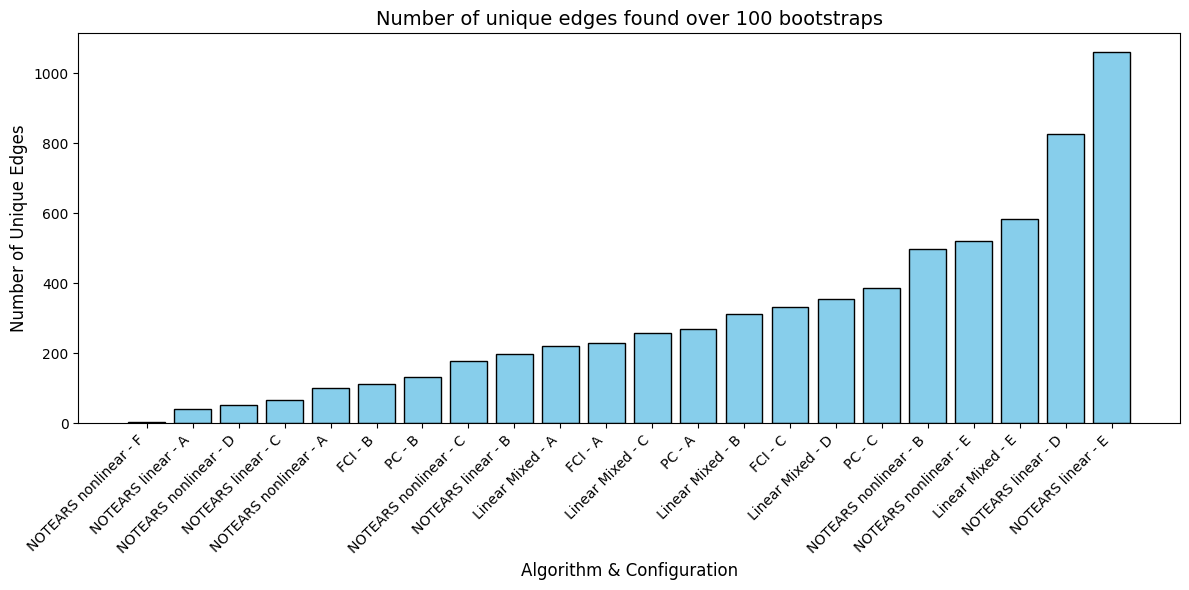

In [10]:
edge_summary_clean = edge_summary.copy()
edge_summary_clean['model'].replace({'pc':'PC', 'fci':'FCI', 'lingam':'Linear Mixed', 'notears_linear':'NOTEARS linear', 'notears_nonlinear':'NOTEARS nonlinear'}, 
                                    inplace=True)
edge_summary_clean.sort_values('model', ascending=True, inplace=True)

# Bar plot of number of edges per model
counts = edge_summary_clean.groupby(["model", 'param_config'])["edge"].nunique().reset_index()
counts = counts.sort_values(by="edge", ascending=True)

# Combine the model and parameter configuration for the x-axis labels
labels = counts['model'].astype(str) + " - " + counts['param_config'].astype(str)

# Create the plot without using plt.figure()
fig, ax = plt.subplots(figsize=(12, 6))

# Create the bar chart
ax.bar(labels, counts["edge"], color='skyblue', edgecolor='black')

# Set labels and title
ax.set_title(f"Number of unique edges found over {bootstrap} bootstraps", fontsize=14)
ax.set_xlabel("Algorithm & Configuration", fontsize=12)
ax.set_ylabel("Number of Unique Edges", fontsize=12)

# Rotate x-axis labels so they are readable and not overlapping
plt.xticks(rotation=45, ha='right')

# Ensure layout fits without clipping
plt.tight_layout()

### Fit summary

In [11]:
ft_model_stg_thr_df = fit_summary.merge(final_num_edges_df, how='left', on=['model', 'param_config', 'threshold']).groupby(
    ['model', 'threshold', 'param_config', 'num_edges_final'], as_index=False).agg(
        r2=('r2','mean'), crps=('crps','mean'), f1=('f1','mean'), kl=('kl','mean'), n_nodes_passed=('passed_metric_threshold','sum'), n_nodes=('node','nunique'))
ft_model_stg_thr_df['pct_nodes_passed'] = ft_model_stg_thr_df['n_nodes_passed']/ft_model_stg_thr_df['n_nodes']

print(len(ft_model_stg_thr_df))
ft_model_stg_thr_df

66


,model,threshold,param_config,num_edges_final,r2,crps,f1,kl,n_nodes_passed,n_nodes,pct_nodes_passed
0,fci,0.20,A,42,0.519957,0.309720,NaN,0.429085,41,43,0.953488
1,fci,0.20,B,41,0.518442,0.309922,NaN,0.443443,41,43,0.953488
2,fci,0.20,C,46,0.501671,0.318916,NaN,0.514164,41,43,0.953488
3,fci,0.35,A,40,0.516360,0.310554,NaN,0.441449,41,43,0.953488
4,fci,0.35,B,32,0.628325,0.299559,NaN,0.399547,41,43,0.953488
5,fci,0.35,C,41,0.516621,0.310416,NaN,0.444621,41,43,0.953488
6,fci,0.50,A,33,0.599986,0.294923,NaN,0.442869,41,43,0.953488
7,fci,0.50,B,28,0.634280,0.295272,NaN,0.440787,41,43,0.953488
8,fci,0.50,C,39,0.516822,0.310058,NaN,0.488806,41,43,0.953488
9,lingam,0.20,A,131,0.307879,0.371139,NaN,0.943930,41,43,0.953488


In [12]:
best_crps_models = ft_model_stg_thr_df[ft_model_stg_thr_df['crps']<0.35][['model', 'param_config', 'threshold', 'num_edges_final', 'crps', 'kl']].sort_values(
    'crps', ascending=True)
print(len(best_crps_models))
best_crps_models

37


,model,param_config,threshold,num_edges_final,crps,kl
6,fci,A,0.50,33,0.294923,0.442869
7,fci,B,0.50,28,0.295272,0.440787
42,notears_nonlinear,D,0.20,29,0.297001,0.560529
4,fci,B,0.35,32,0.299559,0.399547
64,pc,B,0.50,31,0.300738,0.511138
48,notears_nonlinear,D,0.35,26,0.302768,0.532221
54,notears_nonlinear,D,0.50,22,0.305583,0.477935
61,pc,B,0.35,36,0.309346,0.405464
0,fci,A,0.20,42,0.309720,0.429085
1,fci,B,0.20,41,0.309922,0.443443


### Causal Structure

In [13]:
import logging
import datetime, psutil, gc

# Create logs directory
log_dir = Path("logs")
log_dir.mkdir(exist_ok=True)

# Create a unique log file per run
log_filename = log_dir / f"run_{run_label}_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.log"

# Set up logger
logger = logging.getLogger(run_label)
logger.setLevel(logging.DEBUG)

# File handler — writes everything to file
file_handler = logging.FileHandler(log_filename)
file_handler.setLevel(logging.DEBUG)

# Console handler — still prints to notebook
console_handler = logging.StreamHandler()
console_handler.setLevel(logging.INFO)

# Formatter
formatter = logging.Formatter('%(asctime)s | %(levelname)s | %(message)s', 
                               datefmt='%Y-%m-%d %H:%M:%S')
file_handler.setFormatter(formatter)
console_handler.setFormatter(formatter)

logger.addHandler(file_handler)
logger.addHandler(console_handler)

def log_memory(label=""):
    process = psutil.Process(os.getpid())
    mb = process.memory_info().rss / 1e6
    logger.info(f"🧠 Memory [{label}]: {mb:.0f} MB")

In [14]:
import re

def parse_falsification(falsification_str):
    """Parse the falsification summary string to extract key metrics."""
    
    text = str(falsification_str)
    
    # Extract violations: "252/1155 LMCs"
    violation_match = re.search(r'(\d+)/(\d+)\s+LMCs', text)
    if violation_match:
        violations = int(violation_match.group(1))
        total_lmcs = int(violation_match.group(2))
        violation_rate = violations / total_lmcs
    else:
        violations, total_lmcs, violation_rate = np.nan, np.nan, np.nan
    
    # Extract percentile: "better than 100.0% of the permuted DAGs"
    percentile_match = re.search(r'better than\s+([\d.]+)%', text)
    percentile = float(percentile_match.group(1)) if percentile_match else np.nan
    
    # Extract p-value for violations (second p-value in text)
    pval_matches = re.findall(r'p-value:\s*([\d.]+)', text)
    pval_violations = float(pval_matches[1]) if len(pval_matches) > 1 else np.nan
    
    # Extract rejection decision
    rejected = 'we reject the DAG' in text and 'do not reject' not in text
    
    return {
        'lmc_violations': violations,
        'total_lmcs': total_lmcs,
        'violation_rate': violation_rate,
        'percentile_vs_permuted': percentile,
        'p_value': pval_violations,
        'rejected': rejected
    }


def evaluate_structure(model_name, param, threshold, G, df):
    try:
        scm = gcm.InvertibleStructuralCausalModel(G)
        gcm.fit(scm, df)
        
        result = gcm.evaluate_causal_model(
            scm, df,
            evaluate_causal_mechanisms=False,
            compare_mechanism_baselines=False,
            evaluate_invertibility_assumptions=False,
            evaluate_overall_kl_divergence=False,
            evaluate_causal_structure=True
        )
        
        falsification = getattr(result, "graph_falsification", None)
        
        if falsification is not None:
            parsed = parse_falsification(falsification)
        else:
            parsed = {
                'lmc_violations': np.nan, 'total_lmcs': np.nan,
                'violation_rate': np.nan, 'percentile_vs_permuted': np.nan,
                'p_value': np.nan, 'rejected': np.nan
            }
        
        logger.info(f"✓ Done: {model_name} | {param} | {threshold} — "
                   f"violation_rate={parsed['violation_rate']:.3f}, "
                   f"rejected={parsed['rejected']}")
            
    except Exception as e:
        logger.warning(f"✗ Failed: {model_name} | {param} | {threshold} — {e}")
        parsed = {
            'lmc_violations': np.nan, 'total_lmcs': np.nan,
            'violation_rate': np.nan, 'percentile_vs_permuted': np.nan,
            'p_value': np.nan, 'rejected': np.nan
        }
    
    finally:
        try:
            del scm, result, falsification
        except:
            pass
        gc.collect()
    
    return {'model': model_name, 'param_config': param, 'threshold': threshold, **parsed}

graph_dir = Path(f"graph_objects/{data_run_label}")
graph_dir.mkdir(exist_ok=True)
summary_dir = Path(f"summaries/{data_run_label}")
summary_dir.mkdir(exist_ok=True)

# # Run structure evaluation on all candidate models
# structure_results = []

# for _, row in best_crps_models.iterrows():
#     model_name = row['model']
#     param = row['param_config']
#     threshold = row['threshold']
    
#     # Build key to look up saved graph
#     key_str = f"{model_name}_p{param}_b{bootstrap}_{threshold}".replace(".", "_")
#     graph_path = graph_dir / f"{key_str}_graph.pkl"
    
#     if not graph_path.exists():
#         logger.warning(f"Graph not found: {graph_path} — skipping")
#         continue
    
#     logger.info(f"Loading graph: {key_str}")
    
#     try:
#         with open(graph_path, 'rb') as f:
#             G = pickle.load(f)
#     except Exception as e:
#         logger.warning(f"Could not load {graph_path}: {e} — skipping")
#         continue
    
#     result_row = evaluate_structure(model_name, param, threshold, G, final_df_std)
#     structure_results.append(result_row)
    
#     # Save incrementally so overnight run isn't lost if it crashes
#     pd.DataFrame(structure_results).to_csv(
#         summary_dir / f"structure_eval_b{bootstrap}.csv", index=False)
    
#     del G
#     gc.collect()
#     log_memory(f"after {key_str}")

# # Final merged summary
# structure_df = pd.DataFrame(structure_results)
# final_summary = best_crps_models.merge(
#     structure_df, on=['model', 'param_config', 'threshold'], how='left'
# ).sort_values(['rejected', 'violation_rate', 'crps'], ascending=[True, True, True])

# final_summary.to_csv(summary_dir / f"full_model_comparison_b{bootstrap}.csv", index=False)
# final_summary

In [15]:
# best_crps_models.merge(final_summary[['model', 'param_config', 'threshold', 'violation_rate']], how='left', on=['model', 'param_config', 'threshold'])

In [16]:
# # Top 10 graphs with the best violation rates
# final_summary_2 = final_summary.head(10)
# final_summary_2

In [17]:
# # Step 1: Define structural requirement — must have at least one edge FROM infection_episode
# def has_exposure_edges(G, exposure_node='infection_episode'):
#     successors = list(G.successors(exposure_node))
#     has_edges = len(successors) > 0
#     if not has_edges:
#         logger.info(f"Graph has no edges from {exposure_node} — excluded")
#     return has_edges, successors

# # Check all candidate graphs
# exposure_check = []
# for _, row in final_summary.iterrows():
#     key_str = f"{row['model']}_p{row['param_config']}_b{bootstrap}_{row['threshold']}".replace(".", "_")
#     graph_path = graph_dir / f"{key_str}_graph.pkl"
    
#     try:
#         with open(graph_path, 'rb') as f:
#             G = pickle.load(f)
#         has_edges, successors = has_exposure_edges(G)
#         exposure_check.append({
#             'model': row['model'],
#             'param_config': row['param_config'],
#             'threshold': row['threshold'],
#             'has_exposure_edges': has_edges,
#             'exposure_successors': str(successors)
#         })
#         del G
#     except Exception as e:
#         logger.warning(f"Could not load {key_str}: {e}")

# exposure_df = pd.DataFrame(exposure_check)

# # Step 2: Merge and apply all criteria
# decision_df = final_summary_2.merge(
#     exposure_df, on=['model', 'param_config', 'threshold'], how='left'
# )

# # Step 3: Apply inclusion criteria in order
# viable = decision_df[
#     (decision_df['crps'] < 0.35) &                    # good distributional fit
#     (decision_df['rejected'] == False) &               # structure not rejected
#     (decision_df['has_exposure_edges'] == True)        # must have exposure paths
# ].copy()

# # Step 4: Composite score — CRPS weighted most heavily
# viable['crps_score'] = 1 - (viable['crps'] - viable['crps'].min()) / (viable['crps'].max() - viable['crps'].min())
# viable['violation_score'] = 1 - (viable['violation_rate'] - viable['violation_rate'].min()) / (viable['violation_rate'].max() - viable['violation_rate'].min())

# # Edge count score — penalize extremes, reward graphs in a reasonable range
# # Adjust min/max based on your domain knowledge of what's interpretable
# min_edges, max_edges = 25, 60
# viable['edge_score'] = viable['num_edges_final'].apply(
#     lambda n: 1.0 if min_edges <= n <= max_edges else
#               max(0, 1 - (min_edges - n) / min_edges) if n < min_edges else
#               max(0, 1 - (n - max_edges) / max_edges)
# )

# # Weighted composite — CRPS > violation_rate > edge_count
# viable['composite_score'] = (
#     0.50 * viable['crps_score'] +
#     0.30 * viable['violation_score'] +
#     0.20 * viable['edge_score']
# )

# viable_sorted = viable.sort_values('composite_score', ascending=False)

# print(f"Viable candidates after all criteria: {len(viable_sorted)}")
# print(viable_sorted[['model', 'param_config', 'threshold', 'num_edges_final', 
#                        'crps', 'violation_rate', 'exposure_successors',
#                        'composite_score']].to_string())

# viable_sorted.to_csv(summary_dir / f"model_selection_b{bootstrap}.csv", index=False)

### Choosing best model

In [18]:
best_model = 'notears_nonlinear'
best_param_config = "E"

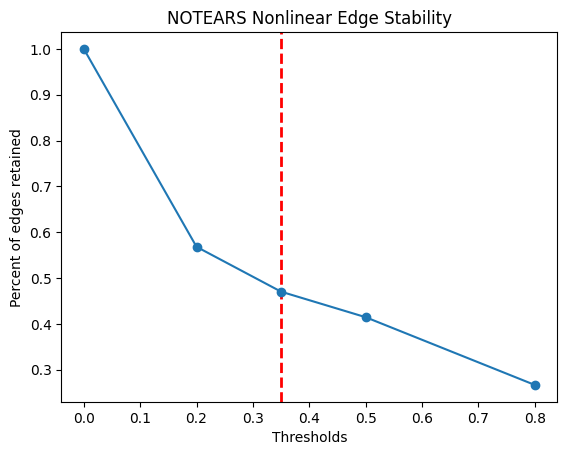

In [19]:
x_nt = [0,0.2,0.35,0.5,0.8]
y_nt = [1]

es_model_thr = edge_summary.groupby(['model', 'param_config'], as_index=False).agg(
    num_edges=('edge', 'nunique'), freq_avg=('freq','mean'), freq_std=('freq','std'), freq_median=('freq','median'))
es_model_thr_2 = edge_summary[edge_summary['freq']>=0.2].groupby(['model', 'param_config'], as_index=False).agg(
    num_edges=('edge', 'nunique'), freq_avg=('freq','mean'), freq_median=('freq','median'))

es_model_thr_35 = edge_summary[edge_summary['freq']>=0.35].groupby(['model', 'param_config'], as_index=False).agg(
    num_edges=('edge', 'nunique'), freq_avg=('freq','mean'), freq_median=('freq','median'))

es_model_thr_5 = edge_summary[edge_summary['freq']>=0.5].groupby(['model', 'param_config'], as_index=False).agg(
    num_edges=('edge', 'nunique'), freq_avg=('freq','mean'), freq_median=('freq','median'))

es_model_thr_8 = edge_summary[edge_summary['freq']>=0.8].groupby(['model', 'param_config'], as_index=False).agg(
    num_edges=('edge', 'nunique'), freq_avg=('freq','mean'), freq_median=('freq','median'))

edges_over_thr = es_model_thr[['model', 'param_config', 'num_edges']].merge(
es_model_thr_2[['model', 'param_config', 'num_edges']].rename(columns={'num_edges':'num_edges_thr_20'}), how='inner', on=['model', 'param_config']).merge(
    es_model_thr_35[['model', 'param_config', 'num_edges']].rename(columns={'num_edges':'num_edges_thr_35'}), how='inner', on=['model', 'param_config']).merge(
        es_model_thr_5[['model', 'param_config', 'num_edges']].rename(columns={'num_edges':'num_edges_thr_50'}), how='inner', on=['model', 'param_config']).merge(
            es_model_thr_8[['model', 'param_config', 'num_edges']].rename(columns={'num_edges':'num_edges_thr_80'}), how='inner', on=['model', 'param_config'])
edges_over_thr['pct_edges_over_20'] = edges_over_thr['num_edges_thr_20'] / edges_over_thr['num_edges']
edges_over_thr['pct_edges_over_35'] = edges_over_thr['num_edges_thr_35'] / edges_over_thr['num_edges']
edges_over_thr['pct_edges_over_50'] = edges_over_thr['num_edges_thr_50'] / edges_over_thr['num_edges']
edges_over_thr['pct_edges_over_80'] = edges_over_thr['num_edges_thr_80'] / edges_over_thr['num_edges']

model_edge_count = edges_over_thr.loc[
    (edges_over_thr.model == best_model)&(edges_over_thr.param_config == best_param_config), 
    ['pct_edges_over_20', 'pct_edges_over_35', 'pct_edges_over_50', 'pct_edges_over_80']].values.flatten().tolist()
y_nt.extend(model_edge_count)

# --- NEW LINE: Add red vertical threshold line ---
plt.axvline(x=0.35, color='red', linestyle='--', linewidth=2, label='Selected Threshold (0.35)')
# -------------------------------------------------

plt.plot(x_nt,y_nt, marker='o')
plt.xlabel("Thresholds")        # Label for the X-axis
plt.ylabel("Percent of edges retained")        # Label for the Y-axis
plt.title("NOTEARS Nonlinear Edge Stability")  # Chart title
plt.show()

In [20]:
best_threshold = 0.35

In [21]:
edges_over_thr[edges_over_thr['model']=='notears_nonlinear']

,model,param_config,num_edges,num_edges_thr_20,num_edges_thr_35,num_edges_thr_50,num_edges_thr_80,pct_edges_over_20,pct_edges_over_35,pct_edges_over_50,pct_edges_over_80
13,notears_nonlinear,A,101,53,33,28,18,0.524752,0.326733,0.277228,0.178218
14,notears_nonlinear,B,497,201,154,138,67,0.404427,0.309859,0.277666,0.134809
15,notears_nonlinear,C,179,65,49,38,24,0.363128,0.273743,0.212291,0.134078
16,notears_nonlinear,D,52,30,27,22,14,0.576923,0.519231,0.423077,0.269231
17,notears_nonlinear,E,521,296,245,216,139,0.568138,0.470250,0.414587,0.266795
18,notears_nonlinear,F,3,3,3,3,3,1.000000,1.000000,1.000000,1.000000


In [22]:
edge_summary_best = edge_summary[(edge_summary['model']==best_model)&(edge_summary['param_config']==best_param_config)]
dag_edges_best = dag_edges[(dag_edges['model']==best_model)&(dag_edges['param_config']==best_param_config)&(dag_edges['threshold']==best_threshold)]

edge_summary_not_best = edge_summary[(edge_summary['model']!=best_model)|(edge_summary['param_config']!=best_param_config)]
dag_edges_not_best = dag_edges[(dag_edges['model']!=best_model)|(dag_edges['param_config']!=best_param_config)]

other_model_edges = dag_edges_not_best.groupby(['edge'], as_index=False).agg(model_count=('model', 'nunique'))
best_model_edges = dag_edges_best[['edge']].drop_duplicates().merge(other_model_edges, how = 'left', on='edge').fillna(0)

print(f"Total edges in graph: {len(best_model_edges)}")
print(f"Number of edges found by at least one other algorithm: {len(best_model_edges[best_model_edges['model_count']>0])}")
print(f"Average number of algorithms that found edges (excl. NTNL): {best_model_edges['model_count'].mean()}")
print(f"Median number of algorithms that found edges (excl. NTNL): {best_model_edges['model_count'].median()}")

Total edges in graph: 243
Number of edges found by at least one other algorithm: 228
Average number of algorithms that found edges (excl. NTNL): 1.9259259259259258
Median number of algorithms that found edges (excl. NTNL): 2.0


In [23]:
len(best_model_edges[best_model_edges['model_count']==0])

## Analysis on the best graph

### Publishing interactive view

In [ ]:
# Load best graph
G_best = graphs[best_model][best_threshold][best_param_config]

#  Load SCM of best graph
scm_best = scms[best_model][best_threshold][best_param_config]

In [26]:
def extract_from_graph(G):
    # Ensure deterministic node order
    node_labels = list(G.nodes())
    index = {node: i for i, node in enumerate(node_labels)}
    n = len(node_labels)
    
    adj_mat = np.zeros((n, n))
    for u, v in G.edges():
        adj_mat[index[u], index[v]] = 1   # or any weight you prefer

    return adj_mat, node_labels

In [27]:
viz_dir = Path(f"visualizations/{data_run_label}")
viz_dir.mkdir(exist_ok=True)

def plot_interactive_graph_phases(adj_mat, node_labels, threshold, img_file, known_bk_edges):
    
    # --- group by phase ---
    def assign_group(name):
        if "pre" in name:
            return "pre"
        elif "acute" in name:
            return "acute"
        elif "post" in name:
            return "post"
        else:
            return "other"
    
    node_groups = [assign_group(name) for name in node_labels]

    GROUP_COLORING = {
        "pre": "skyblue",
        "acute": "lightgreen",
        "post": "salmon",
        "other": "gray"
    }

    net = Network(height="1000px", width="100%", directed=True, notebook=True)
    net.set_options("""
        {
        "physics": {
            "enabled": false
        },
        "edges": {
            "arrows": {
            "to": {"enabled": true, "scaleFactor": 1.0}
            },
            "smooth": false
        },
        "interaction": {
            "dragNodes": true
        }
        }
        """)

    n = len(node_labels)
    unique_groups = sorted(set(node_groups))

    # Layout
    groups_per_row = 3
    group_spacing_x = 900
    group_spacing_y = 900
    max_nodes_per_row = 8
    node_spacing_x = 150
    node_spacing_y = 120

    # Place group blocks
    group_centers = {}
    for idx, grp in enumerate(unique_groups):
        row_idx = idx // groups_per_row
        col_idx = idx % groups_per_row
        group_centers[grp] = (col_idx * group_spacing_x, row_idx * group_spacing_y)

    from collections import defaultdict
    group_indices = defaultdict(int)

    # Add nodes
    for i in range(n):
        grp = node_groups[i]
        center_x, center_y = group_centers[grp]
        local_idx = group_indices[grp]
        group_indices[grp] += 1
        col = local_idx % max_nodes_per_row
        row = local_idx // max_nodes_per_row
        pos_x = center_x + col * node_spacing_x
        pos_y = center_y + row * node_spacing_y

        net.add_node(
            i,
            label=node_labels[i],
            title=node_labels[i],
            x=pos_x,
            y=pos_y,
            color=GROUP_COLORING[grp],
            shape="ellipse",
            font={"align": "center", "size": 16, "color": "black"}
        )

    # Add edges
    number_of_BK_edges = 0
    number_of_non_BK_edges = 0
    
    for i in range(n):
        for j in range(n):
            if adj_mat[i][j] > threshold or adj_mat[i][j] < -threshold:
                if [i, j] in known_bk_edges:
                    edge_color = "black"
                    number_of_BK_edges += 1
                else:
                    edge_color = "blue"
                    number_of_non_BK_edges += 1

                net.add_edge(i, j, arrows="to", color=edge_color, width=2)

    print(f"tr={threshold}, bk_edges={number_of_BK_edges}, non_bk_edges={number_of_non_BK_edges}")

    output_path = viz_dir / f"{img_file}_{threshold}.html"
    net.show(str(output_path))

In [28]:
adj_mat, node_labels = extract_from_graph(G_best)

required_edges_str = [
    ("age", "period_at_covid_start"),
    ("is_female", "period_at_covid_start"),
    ("is_female", "me_cfs")
]
def encode_required_edges(required_edges_str, node_labels):
    label_to_index = {lbl: i for i, lbl in enumerate(node_labels)}
    encoded = []

    for src, tgt in required_edges_str:
        if src not in label_to_index:
            print(f"I cannot confirm this: missing node '{src}' in graph.")
            continue
        if tgt not in label_to_index:
            print(f"I cannot confirm this: missing node '{tgt}' in graph.")
            continue

        encoded.append([label_to_index[src], label_to_index[tgt]])

    return encoded

known_bk_edges = encode_required_edges(required_edges_str, node_labels)

plot_interactive_graph_phases(
    adj_mat=adj_mat,
    node_labels=node_labels,
    threshold=best_threshold,            # whatever threshold you use
    img_file="causal_graph",
    known_bk_edges=known_bk_edges
)

tr=0.35, bk_edges=3, non_bk_edges=238
visualizations/A_1/causal_graph_0.35.html


### Consensus graph edge analysis

In [29]:
def consensus_graph_stability_analysis(G):
    
    # 1. Edge Stability Analysis
    edge_weights = nx.get_edge_attributes(G, 'weight')

    edges = [(u, v, edge_weights.get((u,v), 0)) 
                    for u, v in G.edges()]
    perfectly_stable = [(u, v, edge_weights.get((u,v), 0)) 
                    for u, v in G.edges() if edge_weights.get((u,v),0) >= 1]
    highly_stable = [(u, v, edge_weights.get((u,v), 0)) 
                    for u, v in G.edges() if edge_weights.get((u,v),0) >= .85]
    moderately_stable = [(u, v, edge_weights.get((u,v), 0)) 
                    for u, v in G.edges() if edge_weights.get((u,v),0) >= .6 and edge_weights.get((u,v),0) < .85]
    unstable = [(u, v, edge_weights.get((u,v), 0)) 
                    for u, v in G.edges() if edge_weights.get((u,v),0) >= .35 and edge_weights.get((u,v),0) < .6]
    print(f"\nPerfectly stable edges (≥100%): {len(perfectly_stable)}")
    print(f"Highly stable edges (≥85%): {len(highly_stable)}")
    print(f"Moderately stable edges (60-84%): {len(moderately_stable)}")
    print(f"Unstable edges (<60%): {len(unstable)}")

    # 2. Most Stable Edges
    print("\nEdges with most stable frequencies:")
    print("Top 75 edges:")
    for u,v,w in sorted(highly_stable, key=lambda x: (-x[2]))[:75]:
        print(u,v,w)

In [30]:
consensus_graph_stability_analysis(G_best)


Perfectly stable edges (≥100%): 53
Highly stable edges (≥85%): 128
Moderately stable edges (60-84%): 76
Unstable edges (<60%): 37

Edges with most stable frequencies:
Top 75 edges:
post_funcap_score post_symp_sev_prop 1.0
post_symp_freq_prop post_symp_sev_prop 1.0
pre_symp_sev_prop acute_sleep 1.0
pre_symp_sev_prop acute_emotionally_stressful 1.0
acute_symp_sev_prop post_mentally_demanding 1.0
acute_symp_sev_prop post_emotionally_stressful 1.0
post_crash post_symp_sev_prop 1.0
acute_physically_active acute_mentally_demanding 1.0
acute_sleep post_symp_sev_prop 1.0
pre_mentally_demanding acute_symp_freq_prop 1.0
pre_mentally_demanding acute_symp_sev_prop 1.0
acute_symp_freq_prop post_symp_sev_prop 1.0
acute_symp_freq_prop acute_symp_sev_prop 1.0
acute_num_symp_prop acute_symp_sev_prop 1.0
acute_num_symp_prop acute_symp_freq_prop 1.0
acute_num_symp_prop post_symp_sev_prop 1.0
pre_num_symp_prop pre_symp_sev_prop 1.0
pre_num_symp_prop acute_symp_freq_prop 1.0
pre_num_symp_prop pre_symp_fre

In [31]:
def consensus_graph_treatment_outcome_edge_analysis(G, treatment, outcome):
    
    # 1. Treatment Edge Analysis
    # Analyze the strength of the edges from the treatment
    print("\n1. Treatment Edge Analysis")
    edge_weights = nx.get_edge_attributes(G, 'weight')

    # Find edges FROM treatment
    treatment_edges = [(u, v, edge_weights.get((u,v), 0)) 
                    for u, v in G.edges() if u == treatment]

    print(f"Direct effects of {treatment}:")
    for u, v, weight in sorted(treatment_edges, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {u} → {v}: {weight:.3f}")

    # 2. Outcome Edge Analysis
    # Analyze the strength of the edges to the outcome
    print("\n2. Outcome Edge Analysis")

    # Find edges INTO outcome
    outcome_edges = [(u, v, edge_weights.get((u,v), 0)) 
                    for u, v in G.edges() if v == outcome]

    print(f"Direct edges into {outcome}:")
    for u, v, weight in sorted(outcome_edges, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {u} → {v}: {weight:.3f}")

In [32]:
def analyze_bootstrap_graphs(df, source_vars,
                                     target_vars,
                                     models=None,
                                     max_path_length=None):
    """
    Analyze pathway stability across bootstrap samples for multiple models.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with columns: 'model', 'bootstrap', 'edge'
        where edge is a tuple like ('source', 'target')
    source_vars : list
        List of source/treatment variables (e.g., ['infection_episode'])
    target_vars : list
        List of outcome variables (e.g., ['post_symp_sev_prop', ...])
    models : list, optional
        List of models to analyze. If None, analyzes all models in df
    max_path_length : int, optional
        Maximum path length to consider. If None, no limit
    
    Returns:
    --------
    dict : Nested dictionary with results for each model and source-target pair
    """
    
    if models is None:
        models = df['model'].unique()
    
    results = {}
    
    for model in models:
        print(f"\n{'='*60}")
        print(f"Analyzing: {model}")
        print(f"{'='*60}")
        
        model_df = df[df['model'] == model].copy()
        bootstraps = model_df['bootstrap'].unique()
        n_bootstraps = len(bootstraps)
        
        # Pre-parse all edges and pre-build all graphs
        print(f"Pre-building {n_bootstraps} graphs...")
        bootstrap_graphs = {}
        for bootstrap_id in bootstraps:
            boot_edges = model_df[model_df['bootstrap'] == bootstrap_id]['edge'].tolist()
            boot_edges = [
                ast.literal_eval(e) if isinstance(e, str) else e 
                for e in boot_edges
            ]
            G_boot = nx.DiGraph()
            G_boot.add_edges_from(boot_edges)
            bootstrap_graphs[bootstrap_id] = G_boot
        print(f"Graphs built.")
        
        model_results = {
            'n_bootstraps': n_bootstraps,
            'source_target_pairs': {}
        }
        
        # Analyze each source-target pair
        for source in source_vars:
            for target in target_vars:
                
                print(f"\n--- {source} → {target} ---")
                
                pair_key = f"{source} → {target}"
                pair_results = {
                    'path_existence': 0,  # count of bootstraps with ANY path
                    'direct_edge': 0,     # count of bootstraps with direct edge
                    'all_paths': [],      # store all unique paths found
                    'path_counts': Counter(),  # count occurrences of each path
                    'path_lengths': [],   # distribution of path lengths
                    'mediator_frequency': Counter()  # how often each node mediates
                }
                
                # Analyze each bootstrap
                for bootstrap_id, G_boot in bootstrap_graphs.items():

                    if G_boot.has_node(source):

                        # Check for direct edge
                        if G_boot.has_edge(source, target):
                            pair_results['direct_edge'] += 1

                        # Check for path existence
                        if nx.has_path(G_boot, source, target):
                            pair_results['path_existence'] += 1
                        
                        # Find all paths (with length limit if specified)
                        try:
                            if max_path_length:
                                paths = list(nx.all_simple_paths(G_boot, source, target, 
                                                                cutoff=max_path_length))
                            else:
                                paths = list(nx.all_simple_paths(G_boot, source, target))
                            
                            if paths:

                                mediators_this_bootstrap = set()
                                
                                for path in paths:
                                    # Store path as tuple for counting
                                    path_tuple = tuple(path)
                                    pair_results['path_counts'][path_tuple] += 1
                                    pair_results['path_lengths'].append(len(path))
                                    
                                    # Count mediators (nodes between source and target)
                                    mediators = path[1:-1]
                                    for mediator in mediators:
                                        mediators_this_bootstrap.add(mediator)  # set deduplicates

                                # Count each mediator once per bootstrap 
                                for mediator in mediators_this_bootstrap:
                                    pair_results['mediator_frequency'][mediator] += 1
                        
                        except nx.NetworkXNoPath:
                            continue
                        except Exception as e:
                            # print(f"Warning: Error finding paths in bootstrap {bootstrap_id}: {e}")
                            continue
                
                # Calculate percentages
                pair_results['path_existence_pct'] = 100 * pair_results['path_existence'] / n_bootstraps
                pair_results['direct_edge_pct'] = 100 * pair_results['direct_edge'] / n_bootstraps
                
                # Identify most common paths
                if pair_results['path_counts']:
                    total_path_instances = sum(pair_results['path_counts'].values())
                    pair_results['most_common_paths'] = [
                        {
                            'path': ' → '.join(path),
                            'count': count,
                            'pct_of_bootstraps': 100 * count / n_bootstraps,
                            'pct_of_path_instances': 100 * count / total_path_instances
                        }
                        for path, count in pair_results['path_counts'].most_common(10)
                    ]
                else:
                    pair_results['most_common_paths'] = []
                
                # Path length statistics
                if pair_results['path_lengths']:
                    pair_results['path_length_stats'] = {
                        'mean': np.mean(pair_results['path_lengths']),
                        'median': np.median(pair_results['path_lengths']),
                        'min': min(pair_results['path_lengths']),
                        'max': max(pair_results['path_lengths']),
                        'total_paths_found': len(pair_results['path_lengths'])
                    }
                else:
                    pair_results['path_length_stats'] = None
                
                # Top mediators
                if pair_results['mediator_frequency']:
                    pair_results['top_mediators'] = [
                        {
                            'node': node,
                            'appearances': count,
                            'pct_of_bootstraps': 100 * count / n_bootstraps
                        }
                        for node, count in pair_results['mediator_frequency'].most_common(10)
                    ]
                else:
                    pair_results['top_mediators'] = []
                
                model_results['source_target_pairs'][pair_key] = pair_results
        
        results[model] = model_results
    
    return results

In [33]:
def print_pathway_report(results, source_var, target_var, top_n_paths=5):
    """
    Print a formatted report for a specific source-target pair across all models.
    """
    pair_key = f"{source_var} → {target_var}"
    
    print(f"\n{'='*80}")
    print(f"PATHWAY ANALYSIS REPORT: {pair_key}")
    print(f"{'='*80}\n")
    
    for model, model_data in results.items():
        if pair_key not in model_data['source_target_pairs']:
            continue
            
        pair_data = model_data['source_target_pairs'][pair_key]
        n_bootstraps = model_data['n_bootstraps']
        
        print(f"\n{'-'*80}")
        print(f"Model: {model}")
        print(f"{'-'*80}")
        
        print(f"\n1. PATH EXISTENCE:")
        print(f"   - Any path exists: {pair_data['path_existence_pct']:.1f}% ({pair_data['path_existence']}/{n_bootstraps} bootstraps)")
        print(f"   - Direct edge exists: {pair_data['direct_edge_pct']:.1f}% ({pair_data['direct_edge']}/{n_bootstraps} bootstraps)")
        
        if pair_data['path_existence'] > 0:
            indirect_pct = pair_data['path_existence_pct'] - pair_data['direct_edge_pct']
            print(f"   - Indirect paths only: {indirect_pct:.1f}%")
        
        if pair_data['path_length_stats']:
            stats = pair_data['path_length_stats']
            print(f"\n2. PATH CHARACTERISTICS:")
            print(f"   - Total unique paths: {len(pair_data['path_counts'])}")
            print(f"   - Total path instances: {stats['total_paths_found']}")
            print(f"   - Mean length: {stats['mean']:.1f} nodes")
            print(f"   - Median length: {stats['median']:.1f} nodes")
            print(f"   - Range: {stats['min']}-{stats['max']} nodes")
        
        if pair_data['most_common_paths']:
            print(f"\n3. TOP {min(top_n_paths, len(pair_data['most_common_paths']))} MOST COMMON PATHWAYS:")
            for i, path_info in enumerate(pair_data['most_common_paths'][:top_n_paths], 1):
                print(f"   {i}. {path_info['path']}")
                print(f"      → Appears in {path_info['pct_of_bootstraps']:.1f}% of bootstraps ({path_info['count']} times)")
        
        if pair_data['top_mediators']:
            print(f"\n4. TOP 10 MEDIATING NODES:")
            for i, med_info in enumerate(pair_data['top_mediators'][:10], 1):
                print(f"   {i}. {med_info['node']}")
                print(f"      → Appears in {med_info['pct_of_bootstraps']:.1f}% of bootstraps ({med_info['appearances']} times)")

### Causal Effects

In [34]:
name_map = {'infection_episode':'Infection Episode', 'age':'Age', 'is_female':'Is Female', 'long_covid':'Long COVID', 'me_cfs':'ME/CFS', 'fibromyalgia':'Fibromyalgia',
            'dysautonomia':'Dysautonomia', 'period_at_covid_start':'Period at Infection Start', 'pre_emotionally_stressful':'Pre-Infection Emotional Stress',
            'pre_hr_variability': 'Pre-Infection HRV', 'pre_mentally_demanding':'Pre-Infection Mental Exertion', 'pre_physically_active':'Pre-Infection Physical Exertion',
            'pre_resting_hr':'Pre-Infection Resting Heart Rate', 'pre_sleep':'Pre-Infection Sleep Quality', 'acute_emotionally_stressful':'Acute Infection Emotional Stress',
            'acute_hr_variability':'Acute Infection HRV', 'acute_mentally_demanding':'Acute Infection Mental Exertion', 'acute_physically_active':'Acute Infection Physical Exertion',
            'acute_resting_hr':'Acute Infection Resting Heart Rate', 'acute_sleep':'Acute Infection Sleep Quality', 'post_emotionally_stressful':'Post-Infection Emotional Stress',
            'post_hr_variability':'Post-Infection HRV', 'post_mentally_demanding':'Post-Infection Mental Exertion', 'post_physically_active':'Post-Infection Physical Exertion',
            'post_resting_hr':'Post-Infection Resting Heart Rate', 'post_sleep':'Post-Infection Sleep Quality', 'pre_funcap_score':'Pre-Infection Functional Capacity', 
            'post_funcap_score':'Post-Infection Functional Capacity', 'pre_crash':'Pre-Infection Crash', 'pre_noncovid_infection':'Pre-Infection Non-COVID Infection', 
            'acute_crash':'Acute Infection Crash', 'acute_noncovid_infection':'Acute Infection Non-COVID Infection', 'post_crash':'Post-Infection Crash', 
            'post_noncovid_infection':'Post-Infection Non-COVID Infection', 'pre_num_symp_prop':'Pre-Infection Number of Symptoms', 'pre_symp_sev_prop':'Pre-Infection Symptom Severity', 
            'pre_symp_freq_prop':'Pre-Infection Symptom Frequency', 'acute_num_symp_prop':'Acute Infection Number of Symptoms', 'acute_symp_sev_prop':'Acute Infection Symptom Severity', 
            'acute_symp_freq_prop':'Acute Infection Symptom Frequency', 'post_num_symp_prop':'Post-Infection Number of Symptoms', 'post_symp_sev_prop':'Post-Infection Symptom Severity', 
            'post_symp_freq_prop':'Post-Infection Symptom Frequency', 'pre_breathing_respiration_rate':'Pre-Infection Breathing Respiration Rate'}

In [35]:
def build_forward_inverse_from_registry(r):
    t = r["type"]
    method = r["log_method"]
    eps = r.get("eps", 0)
    shift = r.get("shift", 0)
    max_val = r.get("max_value", None)
    scaler = r.get("scaler", None)

    # --- PROPORTIONS ---
    if t == "proportion":
        if method == "logit":
            def fwd(x):
                x = x.clip(eps,1-eps)
                y = np.log(x/(1-x))
                return scaler.transform(y.reshape(-1,1)).ravel()
            def inv(z):
                y = scaler.inverse_transform(z.reshape(-1,1)).ravel()
                return 1/(1+np.exp(-y))
            return fwd, inv

        else:  # no logit
            def fwd(x):
                return scaler.transform(x.reshape(-1,1)).ravel()
            def inv(z):
                return scaler.inverse_transform(z.reshape(-1,1)).ravel()
            return fwd, inv

    # --- CONTINUOUS / DISCRETE ---
    if method == "log":
        def fwd(x):
            y = np.log(x+eps)
            return scaler.transform(y.reshape(-1,1)).ravel()
        def inv(z):
            y = scaler.inverse_transform(z.reshape(-1,1)).ravel()
            return np.exp(y)-eps
        return fwd, inv

    if method == "log1p":
        def fwd(x):
            y = np.log1p(x - shift)
            return scaler.transform(y.reshape(-1,1)).ravel()
        def inv(z):
            y = scaler.inverse_transform(z.reshape(-1,1)).ravel()
            return np.expm1(y)+shift
        return fwd, inv

    if method == "logcomp":
        def fwd(x):
            y = np.log1p(max_val - x)
            return scaler.transform(y.reshape(-1,1)).ravel()
        def inv(z):
            y = scaler.inverse_transform(z.reshape(-1,1)).ravel()
            return max_val + 1 - np.exp(y)
        return fwd, inv
    
    # --- BINARY ---
    if r["scaler"] is None:
        def fwd(x): 
            return x
        def inv(z): 
            return z
        return fwd, inv

    # no log transform
    def fwd(x):
        return scaler.transform(x.reshape(-1,1)).ravel()
    def inv(z):
        return scaler.inverse_transform(z.reshape(-1,1)).ravel()
    return fwd, inv

def get_nonstd_intervention_values(data, treatment, n_points=6):
    """
    Dynamically infer a clean, interpretable intervention grid for a treatment variable.
    - Keeps binary and small discrete variables as-is.
    - For averaged discrete variables (e.g., 0–3 or 0–10 scales), creates rounded discrete steps.
    - For continuous variables, creates evenly spaced values between 5th and 95th percentile.
    """
    series = data[treatment].dropna()
    min_val, max_val = series.min(), series.max()
    n_unique = series.nunique()

    # --- Case 1: Binary variable
    if n_unique <= 2:
        return sorted(series.unique().astype(float))

    # --- Case 2: True small discrete (integer) scale (e.g., 0–5)
    elif pd.api.types.is_integer_dtype(series) and n_unique < 15:
        return list(sorted(series.unique()))

    # --- Case 3: Averaged discrete variable (e.g., mean of 0–3 or 0–10 ratings)
    elif (max_val - min_val) <= 10 and (max_val - min_val) > 1 and n_unique > 2:
        # Detect the "natural" discrete scale
        step = np.round((max_val - min_val) / 5, 1)  # coarse step
        vals = np.arange(np.floor(min_val), np.ceil(max_val) + step, step)
        vals = np.round(vals).astype(int)
        vals = np.unique(vals[(vals >= np.floor(min_val)) & (vals <= np.ceil(max_val))])

        return vals.tolist()

    # --- Case 4: Continuous variable (e.g., age, HRV)
    else:
        q_low, q_high = series.quantile([0.05, 0.95])
        vals = np.linspace(q_low, q_high, n_points)
        return np.round(vals, 2).tolist()
    
def get_std_intervention_values(data_no_std, treatment, registry, n_points=6):
    """
    Compute intervention grid from non-standardized units, then transform to standardized
    using the saved forward transform.
    """
    nonstd_vals = get_nonstd_intervention_values(data_no_std, treatment, n_points=n_points)
    print(nonstd_vals)

    fwd, _ = build_forward_inverse_from_registry(registry[treatment])
 
    return fwd(np.array(nonstd_vals, dtype=float)).tolist()

def inverse_outcome_transform(col, x, registry):
    _, inv = build_forward_inverse_from_registry(registry[col])
    result = inv(np.atleast_1d(np.array(x, dtype=float)))

    # Return scalar if scalar input, array otherwise
    if np.ndim(x) == 0 or (hasattr(x, '__len__') and len(np.atleast_1d(x)) == 1):
        return float(result.ravel()[0])
    
    return result

In [36]:
def run_mc_intervention(scm, outcome, treatment, val, data, n_reps=100, random_seed=42):
    "Runs interventions with monte_carlo_intervention function"

    return val, monte_carlo_intervention(
        scm,
        {treatment: lambda pre, v=val: v}, # do-operator utilizing range of values v
        outcome=outcome,
        data=data,
        n_reps=n_reps, 
        random_seed=random_seed)

def monte_carlo_intervention(scm, interventions, outcome, data, n_reps=100, 
                 random_seed=42):
    """
    Compute intervention effect on an outcome using GCM.
    
    Parameters
    ----------
    scm : gcm.StructuralCausalModel
        Fitted SCM object.
    interventions : dict
        Node name → callable intervention function (pre_values → post_values).
    outcome : str
        Name of the outcome variable to summarize.
    n_reps : int
        Number of repetitions for Monte Carlo.
    random_seed : int
        Seed for reproducibility.
    
    Returns
    -------
    dict
        {"mean": float,
            "std": float,          # standard deviation or analytic SE
            "95ci": (float, float),# 95% CI
            "raw_means": np.array  # all MC replicates if quick_mode=False}
    """
    gcm.util.general.set_random_seed(random_seed)  # Set once

    raw_means = []
    for i in range(n_reps):
        samples = gcm.interventional_samples(
            scm,
            interventions=interventions,
            observed_data=data
        )
        raw_means.append(samples[outcome].mean())
    
    raw_means = np.array(raw_means)
    mean_val = raw_means.mean()
    std_val = raw_means.std(ddof=1)
    ci_lower, ci_upper = np.percentile(raw_means, [2.5, 97.5])
    
    return {
        "mean": mean_val,
        "std": std_val,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "raw_means": raw_means
        }

In [37]:
def get_meaningful_ylim(outcome, base_outcome, nonstd_data, nonstd_noinf_data, registry, override=False, padding=0.05):
    """
    Returns y-axis limits based on the population range of the outcome variable.
    If base_outcome exists in non-infection data, spans the full range of both datasets.
    If base_outcome == outcome (no phase prefix), variable only exists in infection data.
    """
    if base_outcome != outcome and base_outcome in nonstd_noinf_data.columns and not override:
        # Variable exists in both datasets — span full range of both
        inf_vals = nonstd_data[outcome].dropna()
        noinf_vals = nonstd_noinf_data[base_outcome].dropna()
        lo = min(inf_vals.min(), noinf_vals.min())
        hi = max(inf_vals.max(), noinf_vals.max())
    else:
        # Variable only exists in infection data — use IQR + padding
        raw_vals = nonstd_data[outcome].dropna()
        lo, hi = raw_vals.quantile(0.25), raw_vals.quantile(0.75)

    span = hi - lo
    return lo - padding * span, hi + padding * span

In [38]:
def get_meaningful_xlim(vals, padding=0.05):
    """
    Returns x-axis limits based on the range of the intervention variable.
    """
    lo = vals.min() 
    hi = vals.max()
    
    span = hi - lo
    return lo - padding * span, hi + padding * span

In [39]:
def get_base_variable(var_name):
    """Strip phase prefix from variable name to get base variable."""
    for prefix in ['pre_', 'acute_', 'post_']:
        if var_name.startswith(prefix):
            return var_name[len(prefix):]
    return var_name  # return as-is if no phase prefix found

In [40]:
# Outside the loop — compute baseline stats per variable
baseline_stats = {}
for col in final_df_no_std_noninf.columns:
    if col == 'user_id_pk':
        continue
    vals = final_df_no_std_noninf[col].dropna()
    if len(vals) > 0:
        mean = vals.mean()
        se = vals.std() / np.sqrt(len(vals))
        baseline_stats[col] = {
            'mean': mean,
            'ci_lower': mean - 1.96 * se,
            'ci_upper': mean + 1.96 * se
        }

In [110]:
def run_effect_and_interventions(G, scm, nonstd_data, std_data, nonstd_noinf_data, registry, treatments, outcomes, rq=1, n_reps=100):

    all_results = []
    valid_pairs = []

    # ---- First pass: identify valid treatment–outcome pairs ----
    for treatment in treatments:
        for outcome in outcomes:

            # Check for all paths from treatment to outcome
            paths = list(nx.all_simple_paths(G, source=treatment, target=outcome))
            print(f"Paths from {treatment} to {outcome}:", paths)
            if not paths:
                continue # skip the analysis for combinations that aren't causally linked

            # Add treatment and outcome to variable to plot
            valid_pairs.append((treatment, outcome))
            
    # ---- Skip if no valid causal pairs ----
    if not valid_pairs:
        print("No causal effects detected. Nothing to plot.")
        return
    
    pair_results = {}  # store computed results per pair

    # ---- Second pass: plot only valid pairs ----
    for idx, (treatment, outcome) in enumerate(valid_pairs):

        # ---- GCM INTERVENTION (distributional effects for all values of treatment) ----                    
        print(f"\nPlotting {treatment} → {outcome}")

        # Naming for plots
        treatment_name = name_map[treatment]
        outcome_name = name_map[outcome]
        base_outcome = get_base_variable(outcome)
        base_treatment = get_base_variable(treatment)

        ylim_span_more = get_meaningful_ylim(outcome, base_outcome, nonstd_data, nonstd_noinf_data, registry, override=False)
        ylim_span_less = get_meaningful_ylim(outcome, base_outcome, nonstd_data, nonstd_noinf_data, registry, override=True)

        # Run interventions 
        intervention_vals = get_std_intervention_values(nonstd_data, treatment, registry) # Use the non-standardized data intervals to produce standardized intervals
        res_list = Parallel(n_jobs=6)(
            delayed(run_mc_intervention)(scm, outcome, treatment, val, std_data, n_reps, random_seed=42+i)
            for i, val in enumerate(intervention_vals)
        )
        results_dict = {val: res for val, res in res_list}

        mean_outcomes = {val: res["mean"] for val, res in results_dict.items()}
        ci_lower_outcomes = {val: res["ci_lower"] for val, res in results_dict.items()}
        ci_upper_outcomes = {val: res["ci_upper"] for val, res in results_dict.items()}

        mean_raw = {float(inverse_outcome_transform(treatment, val, registry)): 
                    float(inverse_outcome_transform(outcome, mean_outcome, registry)) for val, mean_outcome in mean_outcomes.items()}
        ci_low_raw = {float(inverse_outcome_transform(treatment, val, registry)): 
                        float(inverse_outcome_transform(outcome, ci_lower_outcome, registry)) for val, ci_lower_outcome in ci_lower_outcomes.items()}
        ci_high_raw = {float(inverse_outcome_transform(treatment, val, registry)): 
                        float(inverse_outcome_transform(outcome, ci_upper_outcome, registry)) for val, ci_upper_outcome in ci_upper_outcomes.items()}
        vals = list(mean_raw.keys())
        means = list(mean_raw.values())
        ci_lower = [ci_low_raw[v] for v in vals]
        ci_upper = [ci_high_raw[v] for v in vals]
        
        # ---- Streamlined Reporting ----
        effect_df = pd.DataFrame({
            "do_val": list(results_dict.keys()),
            "mean": [res["mean"] for res in results_dict.values()]
        })

        # Compute key metrics
        min_val_std, max_val_std = effect_df["do_val"].iloc[0], effect_df["do_val"].iloc[-1]
        min_mean_std, max_mean_std = effect_df["mean"].iloc[0], effect_df["mean"].iloc[-1]
        min_val, max_val = float(inverse_outcome_transform(treatment, min_val_std, registry)), float(inverse_outcome_transform(treatment, max_val_std, registry))
        min_mean, max_mean = float(inverse_outcome_transform(outcome, min_mean_std, registry)), float(inverse_outcome_transform(outcome, max_mean_std, registry))

        # Dose-response slope
        slope = (max_mean - min_mean) / (max_val - min_val)

        # Total changes
        abs_change_std = max_mean_std - min_mean_std
        abs_change = max_mean - min_mean
        rel_change = ((max_mean / min_mean) - 1)
        pct_points = abs_change * 100

        # Print summary
        print(f"\n{'='*60}")
        print(f"{treatment.upper()} → {outcome.upper()}")
        print(f"{'='*60}")
        print(f"Intervention range: {min_val:.1f} to {max_val:.1f}")
        print(f"\nDose-Response Effect:")
        print(f"  • Per unit increase: {slope:.4f}")
        print(f"  • Total change ({min_val:.0f}→{max_val:.0f}): {abs_change:.4f}")
        print(f"  • Relative change: {rel_change:.2f}")
        print(f"{'='*60}\n")

        # Update the same row in all_results
        result_row = {
            "treatment": treatment_name,
            "outcome": outcome_name,
            "min_val": min_val,
            "max_val": max_val, 
            "min_mean_std": min_mean_std,
            "max_mean_std": max_mean_std,
            "min_mean": min_mean,
            "max_mean": max_mean,
            "min_ci_lower": ci_lower[0],      # CI for the minimum intervention
            "min_ci_upper": ci_upper[0],
            "max_ci_lower": ci_lower[-1],     # CI for the maximum intervention
            "max_ci_upper": ci_upper[-1],
            "slope": slope,
            "abs_change_std": abs_change_std,
            "abs_change": abs_change,
            "rel_change": rel_change,
            "pct_points": pct_points
            }
        all_results.append(result_row)
        
        # Check rel_change threshold — only store for plotting if it passes
        threshold_passed = (
            ((rq == 2) | (rq == 3)) & (abs(rel_change) >= 0.04)
        ) | (
            (rq == 1) & (abs(rel_change) >= 0.01)
        )

        if threshold_passed:
            pair_results[(treatment, outcome)] = {
                'vals': vals, 'means': means,
                'ci_lower': ci_lower, 'ci_upper': ci_upper,
                'treatment_name': treatment_name, 'outcome_name': outcome_name,
                'base_outcome': base_outcome, 'base_treatment': base_treatment,
                'ylim_span_more': ylim_span_more,
                'result_row': result_row
            }

    # ---- Only initialize figure now that we know exactly what will be plotted ----
    # Sort plot_pairs by absolute relative change descending
    plot_pairs = sorted(
        pair_results.keys(),
        key=lambda pair: abs(pair_results[pair]['result_row']['rel_change']),
        reverse=True
    )
    if not plot_pairs:
        print("No pairs passed the effect size threshold. Results saved but no plots generated.")
        return
    
    # ---- Create figure only for valid pairs ----
    n_rows = len(plot_pairs)
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, max(3, 4 * n_rows)))
    axes = np.atleast_2d(axes)

    panel_labels = iter('abcdefghijklmnopqrstuvwxyz')
        
    for idx, (treatment, outcome) in enumerate(plot_pairs):
        r = pair_results[(treatment, outcome)]
        # label = next(panel_labels)
        ax_left = axes[idx, 0]
        ax_right = axes[idx, 1]

        # ============================================================
        # FIGURE 1: Intervention Distributions 
        # ============================================================

        # ---- Mean response plot 1 ----
        # Panel label on left plot only — right plot gets the paired letter
        # ax_left.text(0.02, 0.97, f'({label})', transform=ax_left.transAxes,
        #      fontsize=13, fontweight='bold', va='top', ha='left')
        ax_left.plot(r['vals'], r['means'], marker="o", label="Mean outcome")
        ax_left.fill_between(r['vals'], r['ci_lower'], r['ci_upper'], color="lightblue", alpha=0.3, label="95% CI")
        ax_left.set_title(f"Mean {r['outcome_name']} for do-values of {r['treatment_name']}")
        ax_left.set_xlabel(r['treatment_name'], fontsize=10)
        ax_left.set_ylabel(r['outcome_name'], fontsize=10)
        ax_left.grid(True, alpha=0.3)
        ax_left.legend(fontsize=9)

        # ============================================================
        # FIGURE 2: Observational Plots
        # ============================================================

        # ---- Combined: Mean Response + Observational + Baseline ----
        treatment_vals_raw = nonstd_data[treatment].unique()
        treatment_vals_raw = sorted([v for v in treatment_vals_raw if not np.isnan(v)])
        obs_means = []
        obs_stds = []
        obs_counts = []

        for treat_val in treatment_vals_raw:
            subset = nonstd_data[nonstd_data[treatment] == treat_val][outcome].dropna()
            if len(subset) > 0:
                obs_means.append(subset.mean())
                obs_stds.append(subset.std())
                obs_counts.append(len(subset))
            else:
                obs_means.append(np.nan)
                obs_stds.append(np.nan)
                obs_counts.append(0)

        # Calculate standard error for error bars
        obs_se = [s / np.sqrt(n) if n > 0 else 0 for s, n in zip(obs_stds, obs_counts)]

        # Determine if smoothing is needed
        n_unique_treatments = len(np.array(treatment_vals_raw))
        smoothing_threshold = 15  # Smooth if more than 15 unique treatment values

        # Define shared x-range from observational data
        x_min = min(treatment_vals_raw)
        x_max = max(treatment_vals_raw)

        # --- Observational --- (no change to this block)
        if n_unique_treatments > smoothing_threshold:
            window_length = min(31, n_unique_treatments if n_unique_treatments % 2 == 1 else n_unique_treatments - 1)
            if window_length >= 5:
                smoothed_means = savgol_filter(np.array(obs_means), window_length=window_length, polyorder=3)
                ax_right.plot(np.array(treatment_vals_raw), smoothed_means,
                                linewidth=2, color='orange', linestyle='-',
                                label="Observational", zorder=3)
            else:
                ax_right.plot(np.array(treatment_vals_raw), np.array(obs_means),
                                marker="s", linewidth=2, markersize=6,
                                color='orange', label="Observational")
        else:
            ax_right.plot(np.array(treatment_vals_raw), np.array(obs_means),
                            marker="s", linewidth=2, markersize=8,
                            color='orange', label="Observational")

        # --- Baseline reference (no infection) ---
        base_outcome, base_treatment = r['base_outcome'], r['base_treatment']
        if base_outcome in baseline_stats:
            ref = baseline_stats[base_outcome]

            if base_treatment in nonstd_noinf_data.columns:
                ref_data = nonstd_noinf_data[[base_treatment, base_outcome]].dropna()
                
                # Clip baseline x-range to match observational range
                ref_data = ref_data[
                    (ref_data[base_treatment] >= x_min) & 
                    (ref_data[base_treatment] <= x_max)
                ]
                
                n_unique = ref_data[base_treatment].nunique()
                value_counts = ref_data[base_treatment].value_counts(normalize=True)
                is_effectively_discrete = (
                    n_unique <= smoothing_threshold or
                    value_counts.iloc[0] > 0.5
                )

                if not is_effectively_discrete:
                    # Use same bins anchored to observational x-range
                    custom_bins = np.linspace(x_min, x_max, 21)
                    ref_data = ref_data.copy()
                    ref_data['bin'] = pd.cut(ref_data[base_treatment], bins=custom_bins, include_lowest=True)
                    binned = ref_data.groupby('bin', observed=True)[base_outcome].agg(
                        ['mean', 'count']).reset_index()
                    binned['bin_mid'] = binned['bin'].apply(lambda x: x.mid).astype(float)
                    binned = binned.dropna(subset=['bin_mid', 'mean'])

                    ref_x = binned['bin_mid'].values
                    ref_y = binned['mean'].values

                    try:
                        wl = min(11, len(ref_x) if len(ref_x) % 2 == 1 else len(ref_x) - 1)
                        if wl >= 5:
                            s_y = savgol_filter(ref_y, window_length=wl, polyorder=2)
                            ax_right.plot(ref_x, s_y, color='seagreen', linewidth=2,
                                            linestyle='--', label='Baseline (no infection)', zorder=5)
                        else:
                            raise ValueError("window too small")
                    except:
                        ax_right.plot(ref_x, ref_y, color='seagreen', linewidth=2,
                                        linestyle='--', label='Baseline (no infection)', zorder=5)
                else:
                    # Discrete path — groupby on actual values, plots exactly at 0
                    grouped = ref_data.groupby(base_treatment)[base_outcome].agg(
                        ['mean', 'count']).reset_index()
                    ref_x = grouped[base_treatment].values
                    ref_y = grouped['mean'].values

                    ax_right.plot(ref_x, ref_y, color='seagreen', linewidth=2, marker='s',
                                    linestyle='--', label='Baseline (no infection)', zorder=5)
            else:
                ax_right.axhline(ref['mean'], color='seagreen', linestyle='--',
                                    linewidth=2, label='Baseline (no infection)', zorder=5)
        # --- Mean response (causal intervention) ---
        ax_right.plot(r['vals'], r['means'], marker="o", color='steelblue', linewidth=2, label="Intervention")

        ax_right.set_title(f"Mean {r['outcome_name']}: Intervention vs Observational vs Baseline")
        ax_right.set_xlabel(f"{r['treatment_name']}")
        ax_right.set_ylabel(f"{r['outcome_name']}")
        data_min = min(r['vals'])
        data_max = max(r['vals'])
        data_range = data_max - data_min
        ax_right.set_xlim(data_min - 0.05 * data_range, data_max + 0.05 * data_range)         # Adding a 5% margin to both sides
        ax_right.set_ylim(r['ylim_span_more'])
        ax_right.grid(True, alpha=0.3)
        ax_right.legend(fontsize=9)

    plt.tight_layout()
    # Save high-res for manuscript
    fig.savefig(
        f"figures/intervention_plots_rq{rq}.pdf",
        dpi=300, bbox_inches='tight', format='pdf'
    )
    fig.savefig(
        f"figures/intervention_plots_rq{rq}.png",
        dpi=300, bbox_inches='tight'
    )
    plt.show()

    pd.DataFrame(all_results).to_csv(f"summaries/{data_run_label}/intervention_summary_{best_model}_rq{rq}.csv", index=False)   

In [111]:
# Load transformation registry 
with open(f"transform_registry_{data_label}.pkl", "rb") as f:
    registry = pickle.load(f)

#### Scenario 1: Infection Episode -> Outcome Measures

Paths from infection_episode to post_num_symp_prop: []
Paths from infection_episode to post_symp_sev_prop: [['infection_episode', 'post_symp_sev_prop'], ['infection_episode', 'pre_resting_hr', 'acute_resting_hr', 'post_symp_sev_prop'], ['infection_episode', 'pre_resting_hr', 'acute_resting_hr', 'post_symp_freq_prop', 'post_symp_sev_prop'], ['infection_episode', 'pre_resting_hr', 'acute_mentally_demanding', 'acute_emotionally_stressful', 'post_symp_freq_prop', 'post_symp_sev_prop'], ['infection_episode', 'pre_resting_hr', 'acute_mentally_demanding', 'acute_emotionally_stressful', 'acute_resting_hr', 'post_symp_sev_prop'], ['infection_episode', 'pre_resting_hr', 'acute_mentally_demanding', 'acute_emotionally_stressful', 'acute_resting_hr', 'post_symp_freq_prop', 'post_symp_sev_prop'], ['infection_episode', 'pre_resting_hr', 'acute_mentally_demanding', 'acute_emotionally_stressful', 'post_symp_sev_prop'], ['infection_episode', 'pre_resting_hr', 'acute_mentally_demanding', 'post_symp_freq_

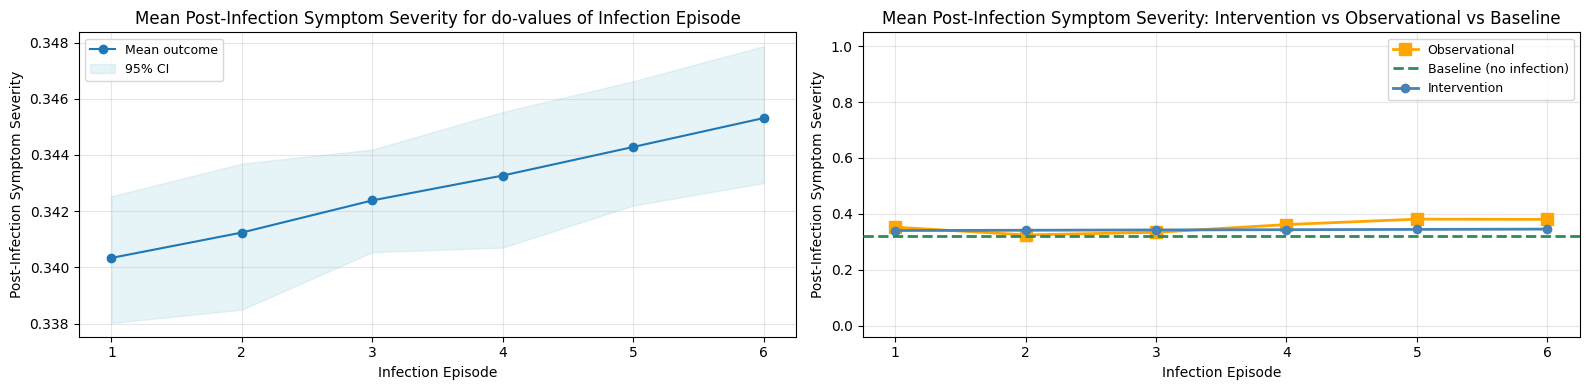

In [112]:
run_effect_and_interventions(G_best, scm_best, final_df_no_std, final_df_std, final_df_no_std_noninf, registry, treatments, outcomes, rq=1, n_reps=200)

In [113]:
# Check for all paths from treatment to outcome
treatment = 'infection_episode'
outcome = 'post_symp_sev_prop'

consensus_graph_treatment_outcome_edge_analysis(G_best, treatment, outcome)


1. Treatment Edge Analysis
Direct effects of infection_episode:
  infection_episode → pre_resting_hr: 0.610
  infection_episode → post_symp_sev_prop: 0.480
  infection_episode → acute_resting_hr: 0.370

2. Outcome Edge Analysis
Direct edges into post_symp_sev_prop:
  post_funcap_score → post_symp_sev_prop: 1.000
  post_symp_freq_prop → post_symp_sev_prop: 1.000
  post_crash → post_symp_sev_prop: 1.000
  acute_sleep → post_symp_sev_prop: 1.000
  acute_symp_freq_prop → post_symp_sev_prop: 1.000
  acute_num_symp_prop → post_symp_sev_prop: 1.000
  pre_resting_hr → post_symp_sev_prop: 1.000
  acute_emotionally_stressful → post_symp_sev_prop: 1.000
  pre_emotionally_stressful → post_symp_sev_prop: 1.000
  post_resting_hr → post_symp_sev_prop: 1.000
  pre_symp_freq_prop → post_symp_sev_prop: 1.000
  post_num_symp_prop → post_symp_sev_prop: 1.000
  pre_mentally_demanding → post_symp_sev_prop: 0.990
  pre_num_symp_prop → post_symp_sev_prop: 0.990
  pre_sleep → post_symp_sev_prop: 0.990
  acute

In [114]:
# Check for all paths from treatment to outcome
treatment = 'infection_episode'
outcome = 'post_symp_freq_prop'

consensus_graph_treatment_outcome_edge_analysis(G_best, treatment, outcome)


1. Treatment Edge Analysis
Direct effects of infection_episode:
  infection_episode → pre_resting_hr: 0.610
  infection_episode → post_symp_sev_prop: 0.480
  infection_episode → acute_resting_hr: 0.370

2. Outcome Edge Analysis
Direct edges into post_symp_freq_prop:
  post_funcap_score → post_symp_freq_prop: 0.990
  post_crash → post_symp_freq_prop: 0.990
  acute_sleep → post_symp_freq_prop: 0.990
  pre_mentally_demanding → post_symp_freq_prop: 0.990
  acute_num_symp_prop → post_symp_freq_prop: 0.990
  pre_num_symp_prop → post_symp_freq_prop: 0.990
  pre_resting_hr → post_symp_freq_prop: 0.990
  pre_sleep → post_symp_freq_prop: 0.990
  acute_mentally_demanding → post_symp_freq_prop: 0.990
  acute_emotionally_stressful → post_symp_freq_prop: 0.990
  acute_crash → post_symp_freq_prop: 0.990
  pre_emotionally_stressful → post_symp_freq_prop: 0.990
  post_resting_hr → post_symp_freq_prop: 0.990
  pre_funcap_score → post_symp_freq_prop: 0.990
  post_num_symp_prop → post_symp_freq_prop: 0.9

In [115]:
# # =============================================================================
# # MAIN ANALYSIS EXECUTION
# # =============================================================================

# # RQ1: infection_episode → symptoms
# print("\n" + "="*80)
# print("RESEARCH QUESTION 1: How do cumulative infections influence symptoms?")
# print("="*80)

# rq1_results = analyze_bootstrap_graphs(
#     df=all_edges,
#     source_vars=treatments,
#     target_vars=outcomes,
#     models=[best_model], 
#     max_path_length=None 
# )

# # Print detailed reports for each treatment-outcome pair
# for treatment in treatments:
#     for outcome in outcomes:
#         print_pathway_report(rq1_results, treatment, outcome, top_n_paths=10)

#### Scenario 2: Infection Episode -> Other Factors

Paths from infection_episode to acute_num_symp_prop: []
Paths from infection_episode to acute_symp_sev_prop: [['infection_episode', 'pre_resting_hr', 'acute_symp_freq_prop', 'acute_symp_sev_prop']]
Paths from infection_episode to acute_symp_freq_prop: [['infection_episode', 'pre_resting_hr', 'acute_symp_freq_prop']]
Paths from infection_episode to acute_emotionally_stressful: [['infection_episode', 'pre_resting_hr', 'acute_mentally_demanding', 'acute_emotionally_stressful'], ['infection_episode', 'pre_resting_hr', 'acute_emotionally_stressful'], ['infection_episode', 'pre_resting_hr', 'acute_symp_freq_prop', 'acute_sleep', 'acute_emotionally_stressful'], ['infection_episode', 'pre_resting_hr', 'acute_symp_freq_prop', 'acute_symp_sev_prop', 'acute_sleep', 'acute_emotionally_stressful'], ['infection_episode', 'pre_resting_hr', 'acute_symp_freq_prop', 'acute_symp_sev_prop', 'acute_emotionally_stressful'], ['infection_episode', 'pre_resting_hr', 'acute_symp_freq_prop', 'acute_emotionally_s

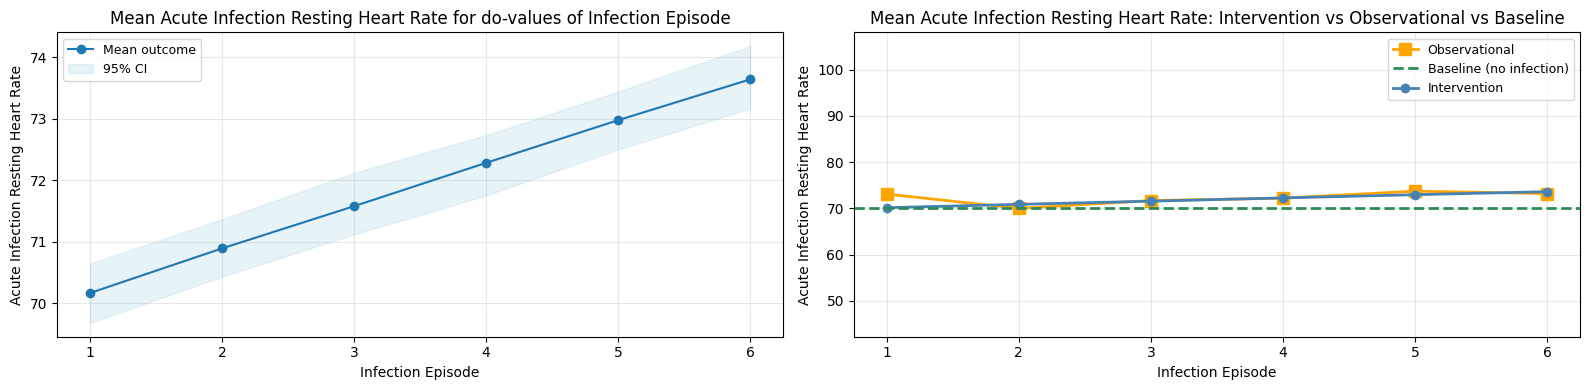

In [116]:
run_effect_and_interventions(G_best, scm_best, final_df_no_std, final_df_std, final_df_no_std_noninf, registry, treatments, other_outcomes, rq=2, n_reps=200)

In [117]:
# Check for all paths from treatment to outcome
treatment = 'infection_episode'
outcome = 'acute_resting_hr'

consensus_graph_treatment_outcome_edge_analysis(G_best, treatment, outcome)


1. Treatment Edge Analysis
Direct effects of infection_episode:
  infection_episode → pre_resting_hr: 0.610
  infection_episode → post_symp_sev_prop: 0.480
  infection_episode → acute_resting_hr: 0.370

2. Outcome Edge Analysis
Direct edges into acute_resting_hr:
  age → acute_resting_hr: 1.000
  pre_sleep → acute_resting_hr: 1.000
  pre_hr_variability → acute_resting_hr: 1.000
  pre_resting_hr → acute_resting_hr: 0.980
  me_cfs → acute_resting_hr: 0.860
  pre_symp_sev_prop → acute_resting_hr: 0.780
  acute_sleep → acute_resting_hr: 0.750
  acute_symp_sev_prop → acute_resting_hr: 0.650
  pre_emotionally_stressful → acute_resting_hr: 0.600
  pre_mentally_demanding → acute_resting_hr: 0.470
  acute_emotionally_stressful → acute_resting_hr: 0.450
  infection_episode → acute_resting_hr: 0.370


In [118]:
# # =============================================================================
# # MAIN ANALYSIS EXECUTION
# # =============================================================================

# # RQ2: infection_episode → other outcomes
# print("\n" + "="*80)
# print("RESEARCH QUESTION 2: How do cumulative infections influence other outcomes?")
# print("="*80)

# rq2_outcomes = ['acute_resting_hr', 'acute_hr_variability']
# print(f"Analyzing {len(rq2_outcomes)} other outcome variables...")

# rq2_results = analyze_bootstrap_graphs(
#     df=all_edges,
#     source_vars=treatments,
#     target_vars=rq2_outcomes,
#     models=[best_model],
#     max_path_length=None
# )

# # Print detailed reports for each treatment-outcome pair
# for treatment in treatments:
#     for outcome in rq2_outcomes:
#         print_pathway_report(rq2_results, treatment, outcome, top_n_paths=10)

#### Scenario 3: Other Factors -> Outcome Measures

Paths from age to post_num_symp_prop: []
Paths from age to post_symp_sev_prop: [['age', 'pre_sleep', 'acute_symp_sev_prop', 'post_symp_sev_prop'], ['age', 'pre_sleep', 'acute_symp_sev_prop', 'post_symp_freq_prop', 'post_symp_sev_prop'], ['age', 'pre_sleep', 'acute_symp_sev_prop', 'acute_sleep', 'post_symp_freq_prop', 'post_symp_sev_prop'], ['age', 'pre_sleep', 'acute_symp_sev_prop', 'acute_sleep', 'post_symp_sev_prop'], ['age', 'pre_sleep', 'acute_symp_sev_prop', 'acute_sleep', 'acute_emotionally_stressful', 'post_symp_freq_prop', 'post_symp_sev_prop'], ['age', 'pre_sleep', 'acute_symp_sev_prop', 'acute_sleep', 'acute_emotionally_stressful', 'acute_resting_hr', 'post_symp_sev_prop'], ['age', 'pre_sleep', 'acute_symp_sev_prop', 'acute_sleep', 'acute_emotionally_stressful', 'acute_resting_hr', 'post_symp_freq_prop', 'post_symp_sev_prop'], ['age', 'pre_sleep', 'acute_symp_sev_prop', 'acute_sleep', 'acute_emotionally_stressful', 'post_symp_sev_prop'], ['age', 'pre_sleep', 'acute_symp_sev_p

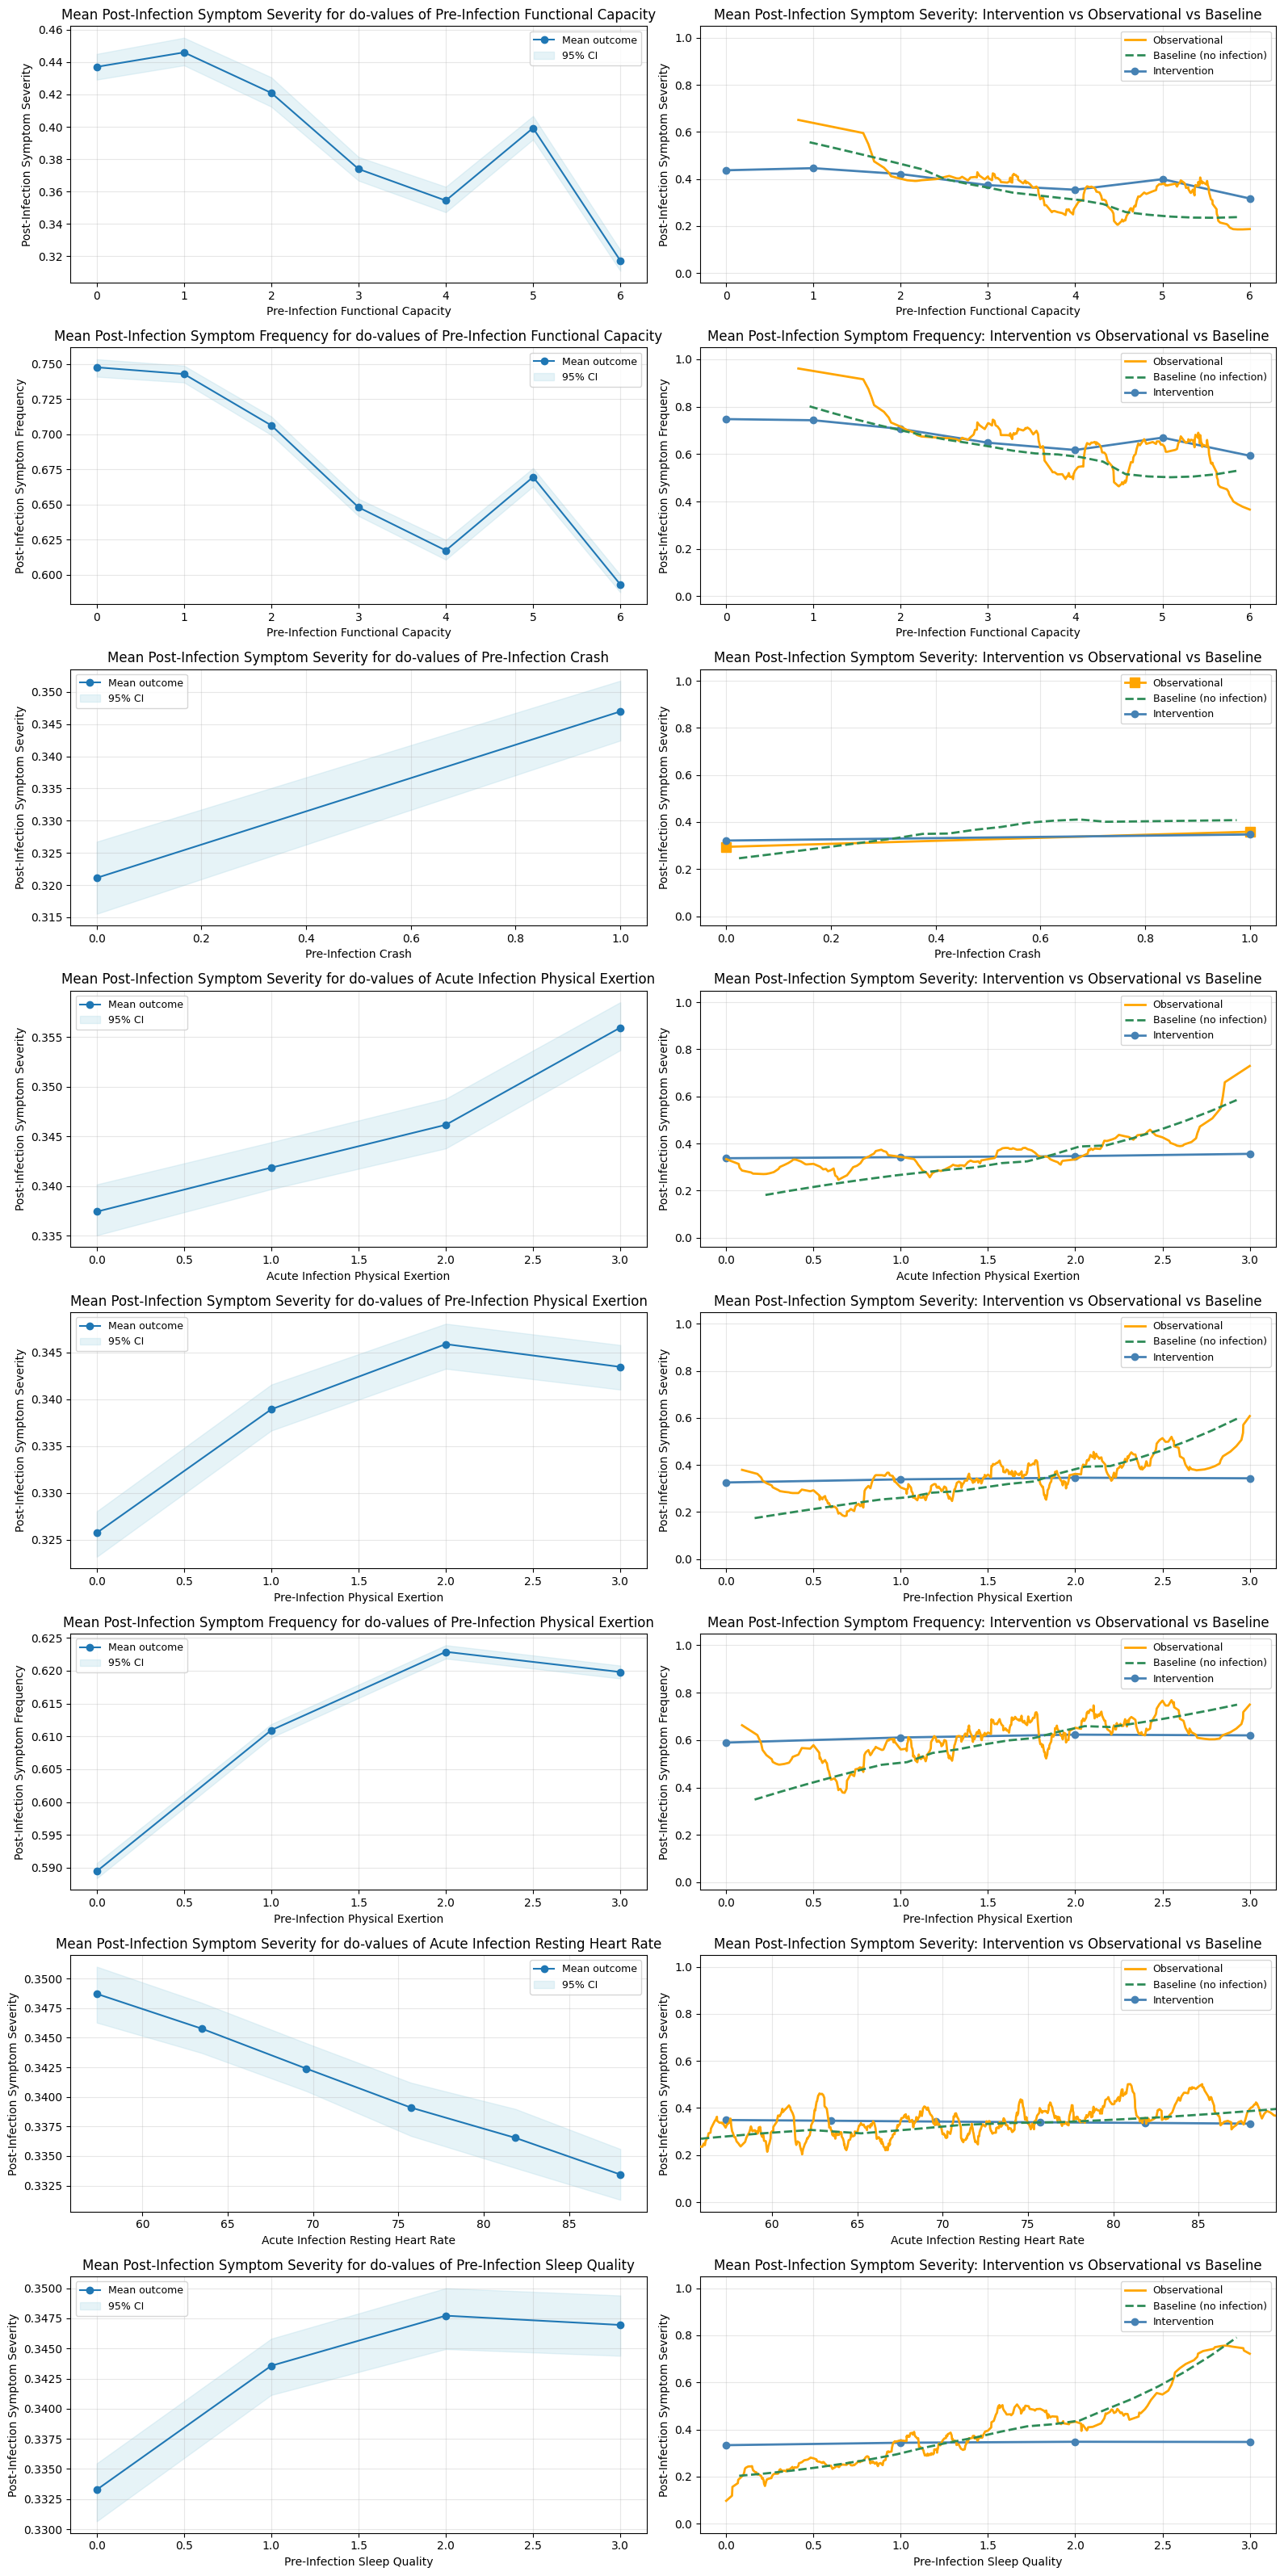

In [119]:
run_effect_and_interventions(G_best, scm_best, final_df_no_std, final_df_std, final_df_no_std_noninf, registry, other_treatments, outcomes, rq=3, n_reps=200)

In [120]:
# Check for all paths from treatment to outcome
treatment = 'pre_funcap_score'
outcome = 'post_symp_sev_prop'

consensus_graph_treatment_outcome_edge_analysis(G_best, treatment, outcome)

# Check for all paths from treatment to outcome
treatment = 'pre_funcap_score'
outcome = 'post_symp_freq_prop'

consensus_graph_treatment_outcome_edge_analysis(G_best, treatment, outcome)

# Check for all paths from treatment to outcome
treatment = 'pre_crash'
outcome = 'post_symp_sev_prop'

consensus_graph_treatment_outcome_edge_analysis(G_best, treatment, outcome)


1. Treatment Edge Analysis
Direct effects of pre_funcap_score:
  pre_funcap_score → acute_symp_freq_prop: 1.000
  pre_funcap_score → pre_symp_freq_prop: 1.000
  pre_funcap_score → pre_symp_sev_prop: 0.990
  pre_funcap_score → post_symp_sev_prop: 0.990
  pre_funcap_score → post_symp_freq_prop: 0.990
  pre_funcap_score → acute_symp_sev_prop: 0.940
  pre_funcap_score → pre_sleep: 0.860
  pre_funcap_score → acute_sleep: 0.740
  pre_funcap_score → post_sleep: 0.700
  pre_funcap_score → acute_emotionally_stressful: 0.520
  pre_funcap_score → pre_resting_hr: 0.450
  pre_funcap_score → pre_emotionally_stressful: 0.410

2. Outcome Edge Analysis
Direct edges into post_symp_sev_prop:
  post_funcap_score → post_symp_sev_prop: 1.000
  post_symp_freq_prop → post_symp_sev_prop: 1.000
  post_crash → post_symp_sev_prop: 1.000
  acute_sleep → post_symp_sev_prop: 1.000
  acute_symp_freq_prop → post_symp_sev_prop: 1.000
  acute_num_symp_prop → post_symp_sev_prop: 1.000
  pre_resting_hr → post_symp_sev_pr

In [121]:
# # =============================================================================
# # MAIN ANALYSIS EXECUTION
# # =============================================================================

# # RQ3: other factors → symptoms
# print("\n" + "="*80)
# print("RESEARCH QUESTION 3: How do other factors influence symptoms?")
# print("="*80)

# print(f"Analyzing {len(other_treatments)} treatment variables...")

# rq3_treatments = ['pre_funcap_score', 'pre_crash']

# rq3_results = analyze_bootstrap_graphs(
#     df=all_edges,
#     source_vars=rq3_treatments,
#     target_vars=outcomes,  # same symptom outcomes as RQ1
#     models=[best_model],
#     max_path_length=None
# )

# # Print summary for top treatments (ones with stable paths)
# print("\n" + "="*80)
# print("RQ3 SUMMARY: Factors with stable pathways to symptoms")
# print("="*80)

# # Print detailed reports for each treatment-outcome pair
# for treatment in rq3_treatments:
#     for outcome in outcomes:
#         print_pathway_report(rq3_results, treatment, outcome, top_n_paths=10)

#### Top edges

In [ ]:
edge_summary_dags = edge_summary.merge(dag_edges, how='right', on=['model', 'edge'])

es_edge_df = edge_summary.groupby(['edge'], as_index=False).agg(
    model_count=('model', 'nunique'),
    freq_sum=('freq', 'sum')
)

# average frequency across the 5 bootstrap models (adjust divisor if needed)
es_edge_df['freq_avg'] = es_edge_df['freq_sum'] / 5

# Use parentheses around each comparison and compare against freq_avg (not freq_sum)
es_edge_df['strong_consensus'] = (es_edge_df['model_count'] >= 4) & (es_edge_df['freq_avg'] >= 0.5)
es_edge_df['moderate_consensus'] = (es_edge_df['model_count'] >= 3) & (es_edge_df['freq_avg'] >= 0.35)
es_edge_df['weak_consensus'] = (es_edge_df['model_count'] >= 2) & (es_edge_df['freq_avg'] >= 0.2)

es_edge_df.head(3)

,edge,model_count,freq_sum,freq_avg,strong_consensus,moderate_consensus,weak_consensus
0,"('acute_crash', 'acute_emotionally_stressful')",2,0.20,0.040,False,False,False
1,"('acute_crash', 'acute_hr_variability')",1,0.72,0.144,False,False,False
2,"('acute_crash', 'acute_mentally_demanding')",3,0.21,0.042,False,False,False


=== SENSITIVITY ANALYSIS: TOP EDGES ===
                                                         edge  freq  Edge Presence in Other Models  freq_avg                  Robustness Category
            ('pre_physically_active', 'acute_symp_freq_prop')  1.00                            1.0    0.2875 Moderately Robust (1-2 other models)
                       ('is_female', 'period_at_covid_start')  1.00                            4.0    2.6900     Highly Robust (3-4 other models)
        ('pre_emotionally_stressful', 'acute_symp_freq_prop')  1.00                            2.0    0.3425 Moderately Robust (1-2 other models)
      ('acute_physically_active', 'acute_mentally_demanding')  1.00                            4.0    0.2525     Highly Robust (3-4 other models)
      ('acute_physically_active', 'acute_mentally_demanding')  1.00                            4.0    0.2525     Highly Robust (3-4 other models)
                ('post_symp_freq_prop', 'post_symp_sev_prop')  1.00                 

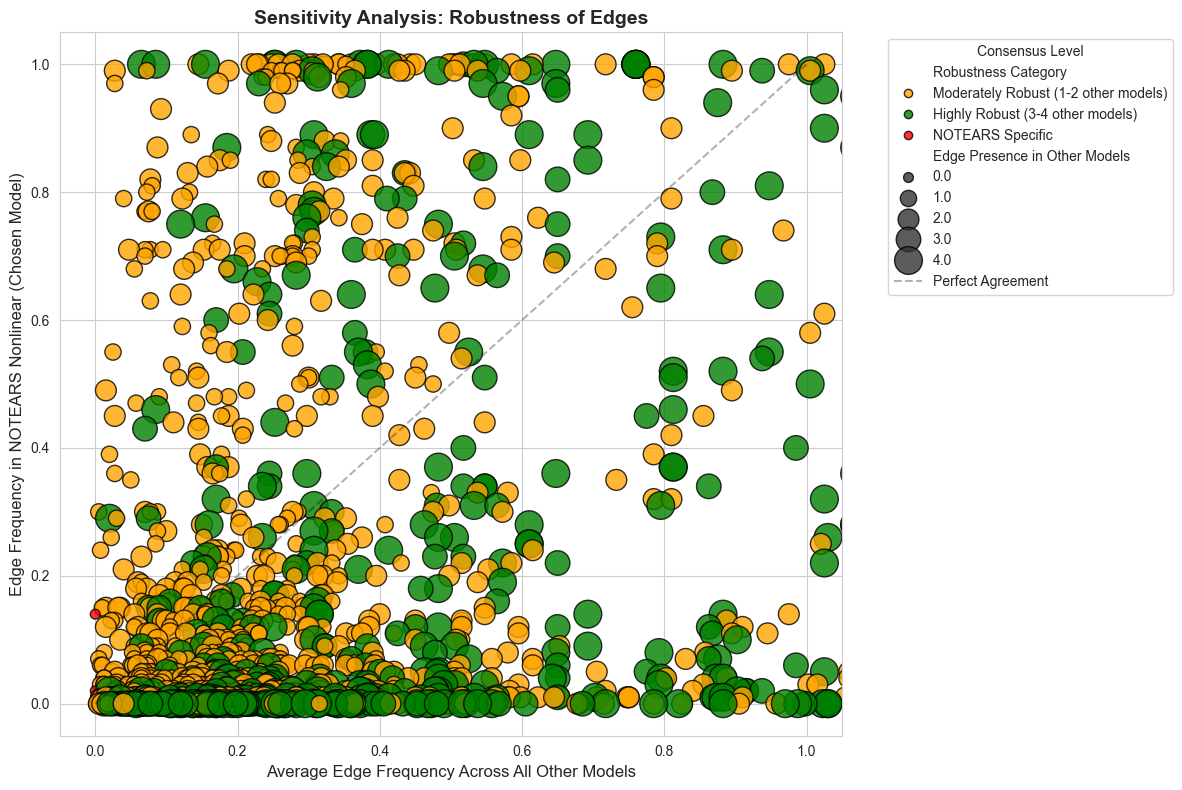


=== SUMMARY FOR PAPER (NOTEARS freq >= 0.35) ===
Total edges above threshold: 511
Highly Robust (3-4 other models):       272 (53.2%)
Moderately Robust (1-2 other models):   239 (46.8%)
NOTEARS Specific (0 other models): 0 (0.0%)

=== STRATIFIED SUMMARY (freq >= 0.35) ===
                 Robustness Category  n_edges  mean_notears_freq  median_notears_freq  mean_crossmodel_freq  median_crossmodel_freq  pct_crossmodel_zero
    Highly Robust (3-4 other models)      272              0.813                 0.89                 1.608                   1.375                  0.0
Moderately Robust (1-2 other models)      239              0.750                 0.76                 0.374                   0.300                  0.0


In [46]:
import seaborn as sns

# 1. Prepare data
other_model_edges = edge_summary[(edge_summary['model']!='notears_nonlinear')].groupby(['edge'], as_index=False).agg(
    model_count=('model', 'nunique'),freq_sum=('freq', 'sum'))
other_model_edges['freq_avg'] = other_model_edges['freq_sum'] / 4
notears_nl_edges = edge_summary[['edge']].drop_duplicates().merge(
    edge_summary[(edge_summary['model']=='notears_nonlinear')], how='left', on='edge').merge(
    other_model_edges[['edge', 'model_count', 'freq_avg']], how='left', on='edge')[['edge', 'freq', 'model_count', 'freq_avg']].fillna(0)
key_edges_df = notears_nl_edges.sort_values('freq', ascending=False)

# 2. Create a "Robustness Score" or Category
def categorize_robustness(row):
    count = row['model_count'] # This is how many OTHER models found it. Total = count + 1 (NOTEARS)
    total_models = count
    
    if total_models >= 3:
        return "Highly Robust (3-4 other models)"
    elif total_models >= 1:
        return "Moderately Robust (1-2 other models)"
    else:
        return "NOTEARS Specific"

key_edges_df['Robustness Category'] = key_edges_df.apply(categorize_robustness, axis=1)
key_edges_df.rename(columns={'model_count':'Edge Presence in Other Models'}, inplace=True)

# 3. Print the Sensitivity Table for the Paper/Supplement
print("=== SENSITIVITY ANALYSIS: TOP EDGES ===")
cols_to_show = ['edge', 'freq', 'Edge Presence in Other Models', 'freq_avg', 'Robustness Category']
# Format the output nicely
output_table = key_edges_df[cols_to_show].copy()
output_table = output_table[['edge', 'freq', 'Edge Presence in Other Models', 'freq_avg', 'Robustness Category']]
print(output_table.to_string(index=False))

# 4. Visualization: Scatter Plot of NOTEARS Frequency vs. Cross-Model Consensus
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

scatter = sns.scatterplot(
    data=key_edges_df,
    x='freq_avg',
    y='freq',
    size='Edge Presence in Other Models',
    sizes=(50, 400),
    hue='Robustness Category',
    palette={'Highly Robust (3-4 other models)': 'green', 
             'Moderately Robust (1-2 other models)': 'orange', 
             'NOTEARS Specific': 'red'},
    alpha=0.8,
    edgecolor='black',
    linewidth=1
)

plt.xlabel('Average Edge Frequency Across All Other Models', fontsize=12)
plt.ylabel('Edge Frequency in NOTEARS Nonlinear (Chosen Model)', fontsize=12)
plt.title('Sensitivity Analysis: Robustness of Edges', fontsize=14, fontweight='bold')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

# Add a diagonal line (y=x)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect Agreement')

plt.legend(title='Consensus Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 5. Summary Statistics
FREQ_THRESHOLD = 0.35
ntnl_35_edges = key_edges_df[key_edges_df['freq'] >= FREQ_THRESHOLD]
total_key_edges = len(ntnl_35_edges)
highly_robust = len(ntnl_35_edges[ntnl_35_edges['Robustness Category'].str.contains("Highly")])
moderately_robust = len(ntnl_35_edges[ntnl_35_edges['Robustness Category'].str.contains("Moderately")])
specific = len(ntnl_35_edges[ntnl_35_edges['Robustness Category'].str.contains("NOTEARS Specific")])

print(f"\n=== SUMMARY FOR PAPER (NOTEARS freq >= {FREQ_THRESHOLD}) ===")
print(f"Total edges above threshold: {total_key_edges}")
print(f"Highly Robust (3-4 other models):       {highly_robust} ({highly_robust/total_key_edges*100:.1f}%)")
print(f"Moderately Robust (1-2 other models):   {moderately_robust} ({moderately_robust/total_key_edges*100:.1f}%)")
print(f"NOTEARS Specific (0 other models): {specific} ({specific/total_key_edges*100:.1f}%)")

# 6. Stratified summary — same filtered population
strat_summary = ntnl_35_edges.groupby('Robustness Category').agg(  # <-- changed from key_edges_df
    n_edges=('freq', 'count'),
    mean_notears_freq=('freq', 'mean'),
    median_notears_freq=('freq', 'median'),
    mean_crossmodel_freq=('freq_avg', 'mean'),
    median_crossmodel_freq=('freq_avg', 'median'),
    pct_crossmodel_zero=('freq_avg', lambda x: round(100*(x == 0).mean(), 1))
).reset_index().round(3)

print(f"\n=== STRATIFIED SUMMARY (freq >= {FREQ_THRESHOLD}) ===")
print(strat_summary.to_string(index=False))

In [ ]:
# Graphs to assess further

fci_A_05_g = graphs['fci'][0.5]['A']
fci_B_05_g = graphs['fci'][0.5]['A']
fci_B_035_g = graphs['fci'][0.35]['A']
notears_nonlinear_D_05_g = graphs['notears_nonlinear'][0.5]['D']
notears_nonlinear_D_035_g = graphs['notears_nonlinear'][0.35]['D']
notears_nonlinear_D_02_g = graphs['notears_nonlinear'][0.2]['D']

models_to_assess = {'fci_A_05_g':fci_A_05_g, 'fci_B_05_g':fci_B_05_g, 'fci_B_035_g':fci_B_035_g, 'notears_nonlinear_D_05_g':notears_nonlinear_D_05_g, 
'notears_nonlinear_D_035_g':notears_nonlinear_D_035_g, 'notears_nonlinear_D_02_g':notears_nonlinear_D_02_g}

In [ ]:
def process_model(model_name, model):

    # Create SCM with original mechanisms
    scm = gcm.InvertibleStructuralCausalModel(model)

    # Fit the causal mechanisms to the data
    gcm.fit(scm, final_df_std)

    # Run evaluation
    eval_result_struct = gcm.evaluate_causal_model(
        scm, final_df_std,
        evaluate_causal_mechanisms=False,  # calculates normalized continuous ranked probability score (all nodes), MSE, normalized MSE, and R2 (continuous), and F1 (categorical)
        compare_mechanism_baselines=False, # compares the causal mechanisms with baseline models to see if there are model choices that perform significantly better
        evaluate_invertibility_assumptions=False, # tests statistical independence between the reconstructed noise and the used input samples
        evaluate_overall_kl_divergence=False, # tests KL divergence between the generated and the observed data
        evaluate_causal_structure=True # evaluates to find substantial evidence to refute the causal graph based on the provided data
    )
    struct = getattr(eval_result_struct, "graph_falsification", {})

    return {'model': model_name, 'causal_structure': struct}

# Use ThreadPoolExecutor (or ProcessPoolExecutor if models are CPU-heavy)
with ThreadPoolExecutor() as executor:
    results = list(executor.map(
        lambda item: process_model(item[0], item[1]),
        models_to_assess.items()
    ))

causal_struct_df = pd.DataFrame(results)
causal_struct_df

Fitting causal mechanism of node post_hr_variability: 100%|██████████| 43/43 [00:00<00:00, 88.55it/s]    /s] 
Fitting causal mechanism of node post_num_symp_prop: 100%|██████████| 43/43 [00:00<00:00, 59.53it/s]        
Fitting causal mechanism of node post_num_symp_prop: 100%|██████████| 43/43 [00:00<00:00, 54.99it/s]
Fitting causal mechanism of node post_hr_variability: 100%|██████████| 43/43 [00:01<00:00, 36.37it/s]it/s]
Fitting causal mechanism of node me_cfs: 100%|██████████| 43/43 [00:01<00:00, 35.60it/s]/s]               
Fitting causal mechanism of node post_hr_variability: 100%|██████████| 43/43 [00:01<00:00, 35.18it/s]    
Test permutations of given graph:   0%|          | 0/50 [00:00<?, ?it/s]









Test permutations of given graph:   2%|▏         | 1/50 [00:51<41:40, 51.03s/it]





Test permutations of given graph:   4%|▍         | 2/50 [01:39<39:34, 49.48s/it]




Test permutations of given graph:   6%|▌         | 3/50 [02:28<38:45, 49.49s/it]





Test permutations of 

KeyboardInterrupt: 